# Local interaction test for the Ca series: 0 mM reference

This notebook reconstructs isotropic random-wave statistics from either the isotropic fits or the `gamma_OH2_best` anisotropic fits. Select the fit source in the configuration cell below. Any fitted stretch is omitted from the local-geometry analysis. The 0 mM condition defines the reference distribution $m(X)$, where $X=(\kappa,\kappa',\kappa\tau)$.

The calculation tests whether the same-contour contribution beyond $k_{\rm eff}\Delta s=1$ depends on $X$, determines the local change relative to 0 mM, and compares reconstructed local distributions with independently traced contours.


Cached contours are kept in the source-specific output folder and are reused when the spectrum and tracing settings are unchanged.


## Spectrum and conditional samples


fit source: aniso; loaded 8 conditions from C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\curvefit\output\ca_aniso\gamma_OH2_best
reference condition: 0 mM Ca
reference k_eff=0.052411293 A^-1, r_sigma_k=0.16195686
stretch parameters, when present, are read only for the audit table and are not used
     0 mM: stable=1.000000, <J>=0.666048
     1 mM: stable=1.000000, <J>=0.666048
    10 mM: stable=1.000000, <J>=0.666048
    24 mM: stable=1.000000, <J>=0.666046
    40 mM: stable=1.000000, <J>=0.666043
    55 mM: stable=1.000000, <J>=0.666041
    70 mM: stable=1.000000, <J>=0.666043
   100 mM: stable=1.000000, <J>=0.666046


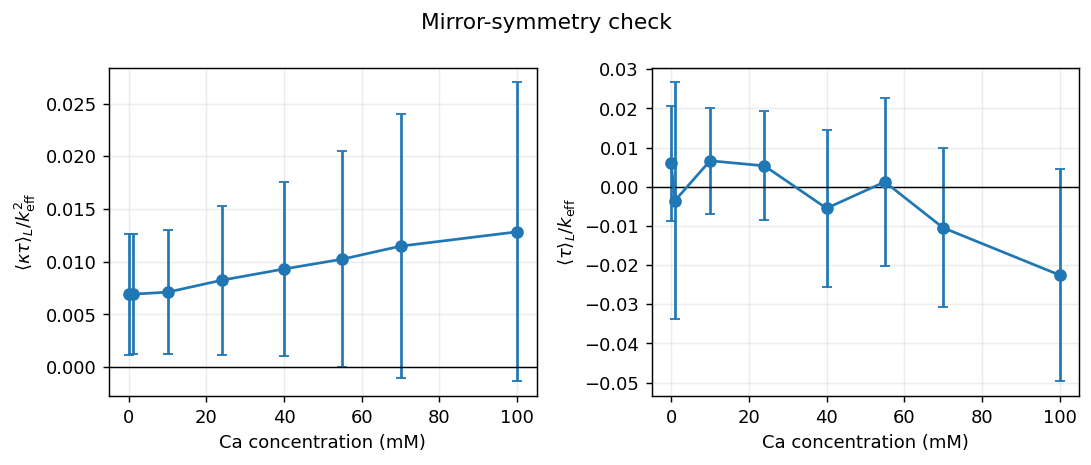

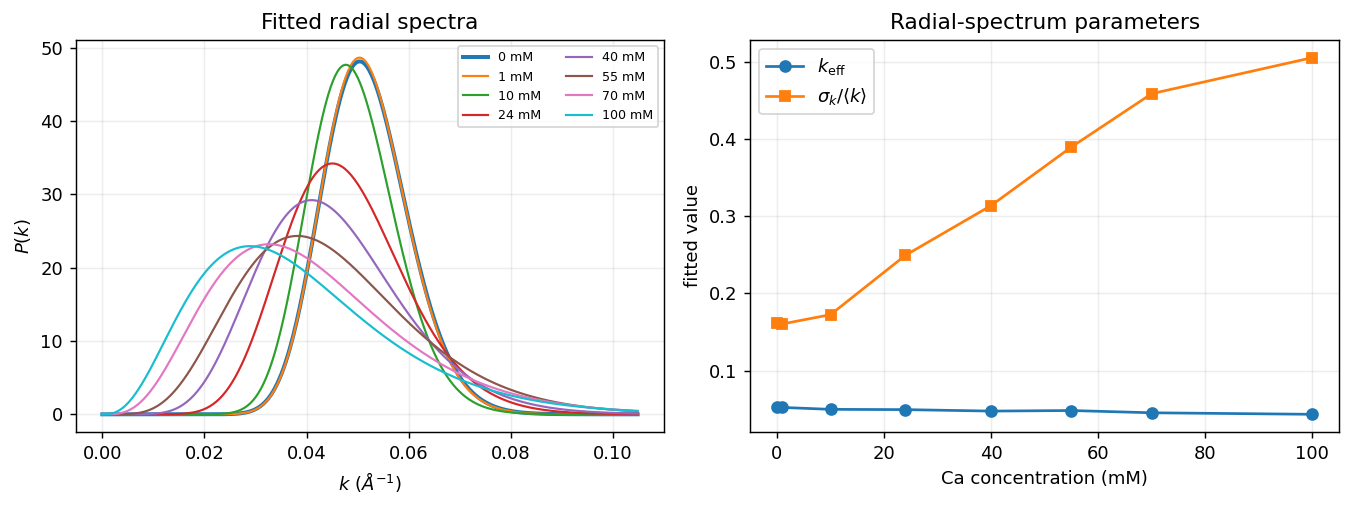

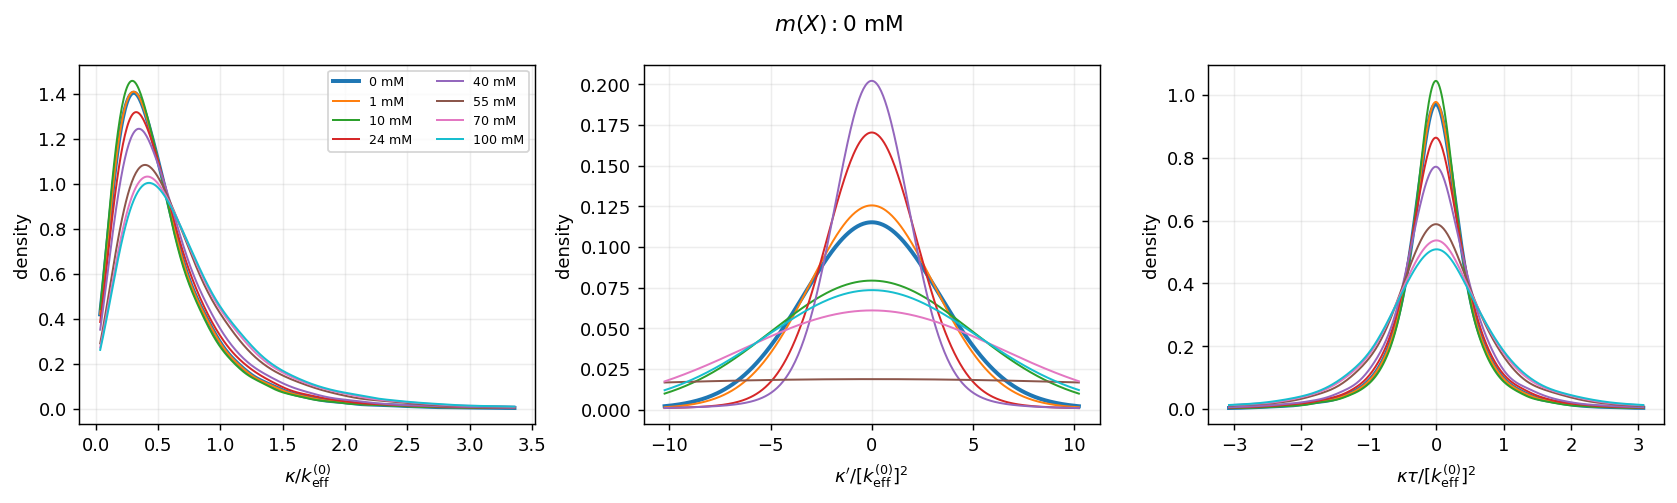

In [1]:
from __future__ import annotations

import csv
import importlib.util
import re
import sys
from itertools import combinations_with_replacement, product
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import gaussian_kde, norm, qmc


HERE = Path.cwd().resolve()
SMPL_ROOT = HERE.parent
PROJECT_ROOT = SMPL_ROOT.parent
FIT_SOURCE = "aniso"  # "iso" or "aniso"
FIT_SOURCES = {
    "iso": {
        "input_dir": HERE / "output" / "ca_iso",
        "pattern": "ca_*mM_gamma_radial_unguided_gamma_radial_isotropic_fit_parameters.csv",
    },
    "aniso": {
        "input_dir": HERE / "output" / "ca_aniso" / "gamma_OH2_best",
        "pattern": "ca_*mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv",
    },
}
if FIT_SOURCE not in FIT_SOURCES:
    raise ValueError(f"FIT_SOURCE must be one of {tuple(FIT_SOURCES)}")
INPUT_DIR = FIT_SOURCES[FIT_SOURCE]["input_dir"]
FIT_PARAMETER_PATTERN = FIT_SOURCES[FIT_SOURCE]["pattern"]
OUTPUT_DIR = HERE / "output" / f"ca_interaction_0mM_{FIT_SOURCE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 190,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.linewidth": 0.8,
})

# Conditional one-point sampling.  Derivatives through third order are enough
# for kappa, kappa', and kappa*tau.
N_LOCAL = 2**15
LOCAL_RANDOM_SEED = 73129

# Reference trajectory settings.  Distances are converted to q=k_eff*s before
# nonlocal pair scores are evaluated.
TRACE_GRID_SIZE = 64
TRACE_NUM_BLOCK = 1
TRACE_NUM_MODES = 256
TRACE_K0 = 5.0
TRACE_RANDOM_SEED = 894894
TRACE_SEED_SPACING = 0.35
TRACE_Q_SPACING = 0.08
TRACE_SPLINE_DENSITY = 32
TRACE_MAX_POINTS = 60000
NONLOCAL_Q_MIN = 1.0
NONLOCAL_Q_MAX = 8.0
CHORD_Q_FLOOR = 0.08
DECAY_RANGES = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
INTERACTION_WEIGHTS = np.array([0.0, 0.25, 0.5, 1.0, 1.5, 2.0])
FLEXIBLE_LOCAL_DEGREE = 4
FLEXIBLE_LOCAL_RIDGE = 1e-4
FLEXIBLE_TRAIN_FRACTION = 0.67


def load_fit_parameters(path: Path) -> dict[str, float]:
    values: dict[str, float] = {}
    with path.open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            values[row["name"]] = float(row["value"])
    return values


def load_radial_fit_series() -> list[dict[str, float | str]]:
    rows: list[dict[str, float | str]] = []
    for path in INPUT_DIR.glob(FIT_PARAMETER_PATTERN):
        values = load_fit_parameters(path)
        match = re.search(r"ca_(\d+(?:\.\d+)?)mM_", path.name)
        if match is None:
            continue
        concentration = float(values.get("salt_concentration_mM", match.group(1)))
        rows.append({
            "condition": f"{concentration:g} mM",
            "concentration_mM": concentration,
            "k_eff": float(values["k_eff"]),
            "mean_k": float(values["mean_k"]),
            "r_sigma_k": float(values["r_sigma_k"]),
            "stretch_ignored": float(values.get("stretch_ratio", np.nan)),
            "source": str(path),
        })
    if not rows:
        raise FileNotFoundError(
            f"No {FIT_SOURCE} fit-parameter files matching {FIT_PARAMETER_PATTERN!r} "
            f"were found under {INPUT_DIR}"
        )
    rows.sort(key=lambda row: float(row["concentration_mM"]))
    return rows


def write_rows(path: Path, rows: list[dict[str, object]]) -> None:
    if not rows:
        return
    fields = list(rows[0])
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


fit_series = load_radial_fit_series()
print(f"fit source: {FIT_SOURCE}; loaded {len(fit_series)} conditions from {INPUT_DIR}")
reference_row = min(fit_series, key=lambda row: abs(float(row["concentration_mM"])))
REFERENCE_SALT = float(reference_row["concentration_mM"])
REFERENCE_K_EFF = float(reference_row["k_eff"])
REFERENCE_WIDTH = float(reference_row["r_sigma_k"])

write_rows(OUTPUT_DIR / "radial_fit_inputs.csv", fit_series)
print(f"reference condition: {REFERENCE_SALT:g} mM Ca")
print(f"reference k_eff={REFERENCE_K_EFF:.8g} A^-1, r_sigma_k={REFERENCE_WIDTH:.8g}")
print("stretch parameters, when present, are read only for the audit table and are not used")


def gamma_radial_moment(order: int, r_sigma_k: float, k_eff: float = 1.0) -> float:
    """Return <k**order> for the fitted gamma radial spectrum."""

    width = float(r_sigma_k)
    mean_k = float(k_eff) / np.sqrt(1.0 + width * width)
    shape = 1.0 / (width * width)
    scale = mean_k * width * width
    return float(np.exp(order * np.log(scale) + gammaln(shape + order) - gammaln(shape)))


def multi_indices_through(max_order: int) -> list[tuple[int, int, int]]:
    indices: list[tuple[int, int, int]] = []
    for total in range(max_order + 1):
        for nx in range(total + 1):
            for ny in range(total - nx + 1):
                indices.append((nx, ny, total - nx - ny))
    return indices


def odd_double_factorial(value: int) -> float:
    result = 1.0
    for item in range(value, 0, -2):
        result *= item
    return result


def spherical_monomial_average(exponents: tuple[int, int, int]) -> float:
    if any(power % 2 for power in exponents):
        return 0.0
    numerator = np.prod([odd_double_factorial(power - 1) for power in exponents])
    return float(numerator / odd_double_factorial(sum(exponents) + 1))


DERIVATIVE_INDICES = multi_indices_through(3)
NONZERO_INDICES = DERIVATIVE_INDICES[1:]
DERIVATIVE_LOOKUP = {multi: index for index, multi in enumerate(NONZERO_INDICES)}


def conditional_derivative_covariance(r_sigma_k: float) -> np.ndarray:
    moments = {order: gamma_radial_moment(order, r_sigma_k) for order in (0, 2, 4, 6)}

    def entry(alpha: tuple[int, int, int], beta: tuple[int, int, int]) -> float:
        exponents = tuple(a + b for a, b in zip(alpha, beta))
        total = sum(exponents)
        if total % 2:
            return 0.0
        sign = (-1.0) ** (sum(beta) + total // 2)
        return sign * moments[total] * spherical_monomial_average(exponents)

    covariance = np.array([
        [entry(alpha, beta) for beta in DERIVATIVE_INDICES]
        for alpha in DERIVATIVE_INDICES
    ])
    conditioned = covariance[1:, 1:] - np.outer(covariance[1:, 0], covariance[1:, 0])
    return 0.5 * (conditioned + conditioned.T)


def expanded_tensor(unique_samples: np.ndarray, order: int) -> np.ndarray:
    tensor = np.empty((len(unique_samples),) + (3,) * order, dtype=float)
    for axes in product(range(3), repeat=order):
        counts = tuple(axes.count(axis) for axis in range(3))
        tensor[(slice(None),) + axes] = unique_samples[:, DERIVATIVE_LOOKUP[counts]]
    return tensor


def contract2(tensor: np.ndarray, first: np.ndarray, second: np.ndarray) -> np.ndarray:
    return np.einsum("nij,ni,nj->n", tensor, first, second, optimize=True)


def contract3(
    tensor: np.ndarray,
    first: np.ndarray,
    second: np.ndarray,
    third: np.ndarray,
) -> np.ndarray:
    return np.einsum("nijk,ni,nj,nk->n", tensor, first, second, third, optimize=True)


def conditional_line_geometry(
    k_eff: float,
    r_sigma_k: float,
    standard_normals: np.ndarray,
) -> dict[str, np.ndarray | float]:
    """Generate coarea-weighted local geometry for one fitted spectrum."""

    covariance = conditional_derivative_covariance(r_sigma_k)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    tolerance = 1e-11 * max(float(np.max(eigenvalues)), 1.0)
    if float(np.min(eigenvalues)) < -tolerance:
        raise RuntimeError("Conditional derivative covariance is not positive semidefinite")
    covariance_half = (eigenvectors * np.sqrt(np.clip(eigenvalues, 0.0, None))) @ eigenvectors.T
    n_components = len(NONZERO_INDICES)
    field1 = standard_normals[:, :n_components] @ covariance_half.T
    field2 = standard_normals[:, n_components:] @ covariance_half.T

    g1, h1, d31 = (expanded_tensor(field1, order) for order in (1, 2, 3))
    g2, h2, d32 = (expanded_tensor(field2, order) for order in (1, 2, 3))
    omega = np.cross(g1, g2)
    jacobian = np.linalg.norm(omega, axis=1)
    stable = jacobian > 1e-12
    g1, h1, d31 = g1[stable], h1[stable], d31[stable]
    g2, h2, d32 = g2[stable], h2[stable], d32[stable]
    omega, jacobian = omega[stable], jacobian[stable]
    tangent = omega / jacobian[:, None]
    matrix = np.stack((g1, g2, tangent), axis=1)
    zeros = np.zeros(len(tangent))
    rhs2 = np.column_stack((
        -contract2(h1, tangent, tangent),
        -contract2(h2, tangent, tangent),
        zeros,
    ))
    r2 = np.linalg.solve(matrix, rhs2[..., None])[..., 0]
    rhs3 = np.column_stack((
        -contract3(d31, tangent, tangent, tangent) - 3.0 * contract2(h1, tangent, r2),
        -contract3(d32, tangent, tangent, tangent) - 3.0 * contract2(h2, tangent, r2),
        -np.einsum("ni,ni->n", r2, r2),
    ))
    r3 = np.linalg.solve(matrix, rhs3[..., None])[..., 0]

    kappa_dimensionless = np.linalg.norm(r2, axis=1)
    regular = kappa_dimensionless > 1e-10
    normal_frame = np.zeros_like(r2)
    normal_frame[regular] = r2[regular] / kappa_dimensionless[regular, None]
    binormal_frame = np.cross(tangent, normal_frame)
    kappa_prime_dimensionless = np.einsum("ni,ni->n", normal_frame, r3)
    kappa_tau_dimensionless = np.einsum("ni,ni->n", binormal_frame, r3)
    weights = jacobian / np.sum(jacobian)

    kappa = float(k_eff) * kappa_dimensionless
    kappa_prime = float(k_eff) ** 2 * kappa_prime_dimensionless
    kappa_tau = float(k_eff) ** 2 * kappa_tau_dimensionless
    local_fourth = (
        (9.0 / 64.0) * kappa**4
        - kappa_prime**2 / 24.0
        - kappa_tau**2 / 24.0
    )
    return {
        "kappa": kappa,
        "kappa_prime": kappa_prime,
        "kappa_tau": kappa_tau,
        "kappa_dimensionless": kappa_dimensionless,
        "kappa_prime_dimensionless": kappa_prime_dimensionless,
        "kappa_tau_dimensionless": kappa_tau_dimensionless,
        "local_second": kappa**2,
        "local_fourth": local_fourth,
        "weights": weights,
        "mean_jacobian_dimensionless": float(np.mean(jacobian)),
        "stable_fraction": float(np.mean(stable)),
    }


sobol = qmc.Sobol(d=2 * len(NONZERO_INDICES), scramble=True, seed=LOCAL_RANDOM_SEED)
unit_samples = sobol.random_base2(int(np.log2(N_LOCAL)))
unit_samples = np.clip(unit_samples, np.finfo(float).eps, 1.0 - np.finfo(float).eps)
standard_normals = norm.ppf(unit_samples)

local_samples: dict[float, dict[str, np.ndarray | float]] = {}
for row in fit_series:
    concentration = float(row["concentration_mM"])
    local_samples[concentration] = conditional_line_geometry(
        float(row["k_eff"]), float(row["r_sigma_k"]), standard_normals
    )
    sample = local_samples[concentration]
    print(
        f"{concentration:6g} mM: stable={sample['stable_fraction']:.6f}, "
        f"<J>={sample['mean_jacobian_dimensionless']:.6f}"
    )


def weighted_quantile(values: np.ndarray, probabilities: np.ndarray, weights: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0.0)
    values, weights = values[valid], weights[valid]
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights)
    cumulative /= cumulative[-1]
    return np.interp(probabilities, cumulative, values)


def weighted_mean_and_standard_error(
    values: np.ndarray,
    weights: np.ndarray,
) -> tuple[float, float]:
    weights = np.asarray(weights, dtype=float)
    weights /= np.sum(weights)
    values = np.asarray(values, dtype=float)
    mean = np.sum(weights * values)
    variance = np.sum(weights * (values - mean) ** 2)
    effective_count = 1.0 / np.sum(weights**2)
    return float(mean), float(np.sqrt(variance / effective_count))


torsion_mean_rows: list[dict[str, object]] = []
for row in fit_series:
    concentration = float(row["concentration_mM"])
    k_eff = float(row["k_eff"])
    sample = local_samples[concentration]
    weights = np.asarray(sample["weights"])
    kappa = np.asarray(sample["kappa"])
    kappa_tau_dimensionless = np.asarray(sample["kappa_tau"]) / k_eff**2
    tau_dimensionless = np.asarray(sample["kappa_tau"]) / (kappa * k_eff)
    mean_kappa_tau, se_kappa_tau = weighted_mean_and_standard_error(
        kappa_tau_dimensionless, weights
    )
    mean_tau, se_tau = weighted_mean_and_standard_error(tau_dimensionless, weights)
    torsion_mean_rows.append({
        "concentration_mM": concentration,
        "mean_kappa_tau_over_k_eff2": mean_kappa_tau,
        "sampling_se_kappa_tau_over_k_eff2": se_kappa_tau,
        "mean_tau_over_k_eff": mean_tau,
        "sampling_se_tau_over_k_eff": se_tau,
    })
write_rows(OUTPUT_DIR / "torsion_symmetry_check.csv", torsion_mean_rows)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6))
axes[0].errorbar(
    [float(row["concentration_mM"]) for row in torsion_mean_rows],
    [float(row["mean_kappa_tau_over_k_eff2"]) for row in torsion_mean_rows],
    yerr=[float(row["sampling_se_kappa_tau_over_k_eff2"]) for row in torsion_mean_rows],
    marker="o", capsize=3,
)
axes[0].axhline(0.0, color="k", lw=0.8)
axes[0].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle\kappa\tau\rangle_L/k_{\rm eff}^2$")
axes[1].errorbar(
    [float(row["concentration_mM"]) for row in torsion_mean_rows],
    [float(row["mean_tau_over_k_eff"]) for row in torsion_mean_rows],
    yerr=[float(row["sampling_se_tau_over_k_eff"]) for row in torsion_mean_rows],
    marker="o", capsize=3,
)
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle\tau\rangle_L/k_{\rm eff}$")
fig.suptitle("Mirror-symmetry check")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "torsion_symmetry_check.png")
plt.show()


def kde_curve(
    values: np.ndarray,
    weights: np.ndarray,
    grid: np.ndarray,
    bandwidth: float | None = None,
) -> np.ndarray:
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0.0)
    density = gaussian_kde(values[valid], weights=weights[valid], bw_method=bandwidth)
    return density(grid)


DISCRETE_SALT_COLORS = (
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#17becf",  # cyan
)
if len(fit_series) > len(DISCRETE_SALT_COLORS):
    raise ValueError("Add more discrete colors for the loaded Ca series")
colors = DISCRETE_SALT_COLORS[:len(fit_series)]
salt_color_map = {
    float(row["concentration_mM"]): color
    for row, color in zip(fit_series, colors)
}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for color, row in zip(colors, fit_series):
    width = float(row["r_sigma_k"])
    k_eff = float(row["k_eff"])
    mean_k = k_eff / np.sqrt(1.0 + width**2)
    shape = 1.0 / width**2
    scale = mean_k * width**2
    grid = np.linspace(0.0, 2.0 * max(float(item["k_eff"]) for item in fit_series), 500)
    density = np.zeros_like(grid)
    positive = grid > 0.0
    density[positive] = np.exp(
        (shape - 1.0) * np.log(grid[positive])
        - grid[positive] / scale
        - gammaln(shape)
        - shape * np.log(scale)
    )
    label = str(row["condition"])
    lw = 2.2 if float(row["concentration_mM"]) == REFERENCE_SALT else 1.2
    axes[0].plot(grid, density, color=color, lw=lw, label=label)
axes[0].set(xlabel=r"$k$ ($\AA^{-1}$)", ylabel=r"$P(k)$", title="Fitted radial spectra")
axes[0].legend(ncol=2, fontsize=7)
axes[1].plot(
    [float(row["concentration_mM"]) for row in fit_series],
    [float(row["k_eff"]) for row in fit_series],
    "o-", label=r"$k_{\rm eff}$",
)
axes[1].plot(
    [float(row["concentration_mM"]) for row in fit_series],
    [float(row["r_sigma_k"]) for row in fit_series],
    "s-", label=r"$\sigma_k/\langle k\rangle$",
)
axes[1].set(xlabel="Ca concentration (mM)", ylabel="fitted value", title="Radial-spectrum parameters")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "isotropic_radial_spectra.png")
plt.show()


geometry_specs = (
    ("kappa", REFERENCE_K_EFF, r"$\kappa/k_{\rm eff}^{(0)}$"),
    ("kappa_prime", REFERENCE_K_EFF**2, r"$\kappa'/[k_{\rm eff}^{(0)}]^2$"),
    ("kappa_tau", REFERENCE_K_EFF**2, r"$\kappa\tau/[k_{\rm eff}^{(0)}]^2$"),
)
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))
for axis, (name, scale, label) in zip(axes, geometry_specs):
    reference = local_samples[REFERENCE_SALT]
    reference_values = np.asarray(reference[name]) / scale
    reference_weights = np.asarray(reference["weights"])
    bounds = weighted_quantile(reference_values, np.array([0.005, 0.995]), reference_weights)
    if name != "kappa":
        symmetric = max(abs(bounds[0]), abs(bounds[1]))
        bounds = np.array([-symmetric, symmetric])
    grid = np.linspace(bounds[0], bounds[1], 420)
    for color, row in zip(colors, fit_series):
        concentration = float(row["concentration_mM"])
        sample = local_samples[concentration]
        lw = 2.2 if concentration == REFERENCE_SALT else 1.1
        axis.plot(
            grid,
            kde_curve(np.asarray(sample[name]) / scale, np.asarray(sample["weights"]), grid),
            color=color,
            lw=lw,
            label=str(row["condition"]),
        )
    axis.set(xlabel=label, ylabel="density")
axes[0].legend(ncol=2, fontsize=7)
fig.suptitle(r"$m(X): 0\ {\rm mM}$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "local_geometry_distributions.png")
plt.show()


## Traced reference contour


In [2]:
# --- Trace the isotropic reference field -----------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import rw_line_network as rwn

root_scattering_spec = importlib.util.spec_from_file_location(
    "rw_line_scattering_interaction", PROJECT_ROOT / "rw_line_scattering.py"
)
root_scattering = importlib.util.module_from_spec(root_scattering_spec)
sys.modules[root_scattering_spec.name] = root_scattering
root_scattering_spec.loader.exec_module(root_scattering)


def packed_cells(cells: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    lengths = np.asarray([len(cell) for cell in cells], dtype=int)
    offsets = np.concatenate(([0], np.cumsum(lengths)))
    points = np.vstack(cells) if cells else np.empty((0, 3))
    return points, offsets


def unpacked_cells(points: np.ndarray, offsets: np.ndarray) -> list[np.ndarray]:
    return [points[offsets[i]:offsets[i + 1]] for i in range(len(offsets) - 1)]


trace_cache = OUTPUT_DIR / "reference_isotropic_trace.npz"


def trace_k0_for_spectrum(k_eff: float, width: float) -> float:
    reference_mean_k = REFERENCE_K_EFF / np.sqrt(1.0 + REFERENCE_WIDTH**2)
    mean_k = float(k_eff) / np.sqrt(1.0 + float(width) ** 2)
    return TRACE_K0 * mean_k / reference_mean_k


def build_isotropic_trace(
    width: float,
    trace_k0: float,
    random_seed: int,
) -> tuple[list[np.ndarray], list[np.ndarray], list[np.ndarray], list[np.ndarray], float]:
    rwn.GRID_SIZE = TRACE_GRID_SIZE
    rwn.NUM_BLOCK = TRACE_NUM_BLOCK
    rwn.BLOCK_OVERLAP = 0
    rwn.RANDOM_SEED = random_seed
    rwn.NUM_MODES = (TRACE_NUM_MODES, TRACE_NUM_MODES, TRACE_NUM_MODES)
    rwn.K_DISTRIBUTION = "gamma_radial"
    rwn.K0 = (trace_k0, trace_k0, trace_k0)
    rwn.r_SIGMA_K = (width, width, width)
    rwn.SHARED_K_VECTORS = False
    rwn.COUPLE_PHI2_PHI3 = False
    rwn.USE_VORTEX_TRACING = True
    rwn.VORTEX_FACE_PREFILTER = True
    rwn.SMOOTH_VORTEX_LINES = False

    rng = np.random.default_rng(random_seed)
    k_sets = rwn.make_field_k_sets(
        rwn.NUM_MODES, rwn.K_DISTRIBUTION, rng, shared_k_vectors=False
    )
    mean_k2 = 0.5 * (
        np.mean(np.einsum("ni,ni->n", k_sets.phi1, k_sets.phi1))
        + np.mean(np.einsum("ni,ni->n", k_sets.phi2, k_sets.phi2))
    )
    trace_k_eff = (2.0 * np.pi / TRACE_GRID_SIZE) * np.sqrt(mean_k2)
    coefficients1 = rwn.make_wave_coefficients(k_sets.phi1, rng)
    coefficients2 = rwn.make_wave_coefficients(k_sets.phi2, rng)

    def wave_jet(points: np.ndarray, coefficients: object, order: int = 0) -> tuple[np.ndarray, ...]:
        q_vectors = (2.0 * np.pi / TRACE_GRID_SIZE) * coefficients.k_vectors
        phase = points @ q_vectors.T + coefficients.phases
        cosine_weight = np.cos(phase) * coefficients.amplitudes
        sine_weight = np.sin(phase) * coefficients.amplitudes
        value = np.sum(cosine_weight, axis=1)
        if order == 0:
            return (value,)
        gradient = (-sine_weight) @ q_vectors
        if order == 1:
            return value, gradient
        hessian = np.einsum(
            "nm,mi,mj->nij", -cosine_weight, q_vectors, q_vectors, optimize=True
        )
        if order == 2:
            return value, gradient, hessian
        third = np.einsum(
            "nm,mi,mj,mk->nijk", sine_weight, q_vectors, q_vectors, q_vectors, optimize=True
        )
        return value, gradient, hessian, third

    def normal_plane_coefficients(
        g1: np.ndarray,
        g2: np.ndarray,
        rhs1: np.ndarray,
        rhs2: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        a11 = np.einsum("ij,ij->i", g1, g1)
        a12 = np.einsum("ij,ij->i", g1, g2)
        a22 = np.einsum("ij,ij->i", g2, g2)
        determinant = a11 * a22 - a12 * a12
        safe = np.abs(determinant) > 1e-14 * np.maximum(a11 * a22, 1.0)
        c1 = np.zeros_like(rhs1)
        c2 = np.zeros_like(rhs2)
        c1[safe] = (rhs1[safe] * a22[safe] - rhs2[safe] * a12[safe]) / determinant[safe]
        c2[safe] = (rhs2[safe] * a11[safe] - rhs1[safe] * a12[safe]) / determinant[safe]
        return c1, c2, safe

    def project_to_line(points: np.ndarray, iterations: int = 3) -> np.ndarray:
        projected = points.copy()
        for _ in range(iterations):
            f1, g1 = wave_jet(projected, coefficients1, order=1)
            f2, g2 = wave_jet(projected, coefficients2, order=1)
            c1, c2, safe = normal_plane_coefficients(g1, g2, -f1, -f2)
            projected[safe] += c1[safe, None] * g1[safe] + c2[safe, None] * g2[safe]
        return projected

    def geometry_at_points(points: np.ndarray, batch_size: int = 4096) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        tangents = np.empty_like(points)
        r2_values = np.empty_like(points)
        r3_values = np.empty_like(points)
        for start in range(0, len(points), batch_size):
            stop = min(start + batch_size, len(points))
            local = points[start:stop]
            _, g1, h1, d31 = wave_jet(local, coefficients1, order=3)
            _, g2, h2, d32 = wave_jet(local, coefficients2, order=3)
            tangent = np.cross(g1, g2)
            tangent /= np.linalg.norm(tangent, axis=1)[:, None]
            matrix = np.stack((g1, g2, tangent), axis=1)
            zeros = np.zeros(len(local))
            rhs2 = np.column_stack((
                -contract2(h1, tangent, tangent),
                -contract2(h2, tangent, tangent),
                zeros,
            ))
            r2 = np.linalg.solve(matrix, rhs2[..., None])[..., 0]
            rhs3 = np.column_stack((
                -contract3(d31, tangent, tangent, tangent) - 3.0 * contract2(h1, tangent, r2),
                -contract3(d32, tangent, tangent, tangent) - 3.0 * contract2(h2, tangent, r2),
                -np.einsum("ni,ni->n", r2, r2),
            ))
            r3 = np.linalg.solve(matrix, rhs3[..., None])[..., 0]
            tangents[start:stop] = tangent
            r2_values[start:stop] = r2
            r3_values[start:stop] = r3
        return tangents, r2_values, r3_values

    phi1, phi2, _ = root_scattering._build_fields()
    segments = rwn.trace_vortex_segments(phi1, phi2)
    connected = rwn.smooth_vortex_polydata(segments)
    seed_cells: list[np.ndarray] = []
    for cell in root_scattering._line_cells(connected):
        points = root_scattering._sample_line_cell_by_arclength(cell, TRACE_SEED_SPACING)
        if len(points) > 3:
            seed_cells.append(points[:-1])
    seed_points, seed_offsets = packed_cells(seed_cells)
    projected = project_to_line(seed_points)
    projected_cells = unpacked_cells(projected, seed_offsets)
    fine_spacing = TRACE_Q_SPACING / trace_k_eff
    interpolated_cells: list[np.ndarray] = []
    for points in projected_cells:
        segment_length = np.linalg.norm(np.diff(points, axis=0), axis=1)
        points = points[np.concatenate(([True], segment_length > 1e-10))]
        if len(points) < 4:
            continue
        arclength = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(points, axis=0), axis=1))))
        sample_s = np.arange(0.0, arclength[-1], fine_spacing)
        if len(sample_s) < 8:
            continue
        interpolated_cells.append(np.column_stack([
            CubicSpline(arclength, points[:, axis], bc_type="natural")(sample_s)
            for axis in range(3)
        ]))
    fine_points, fine_offsets = packed_cells(interpolated_cells)
    fine_points = project_to_line(fine_points, iterations=2)
    point_cells = unpacked_cells(fine_points, fine_offsets)
    tangent, r2_values, r3_values = geometry_at_points(fine_points)
    tangent_cells = unpacked_cells(tangent, fine_offsets)
    r2_cells = unpacked_cells(r2_values, fine_offsets)
    r3_cells = unpacked_cells(r3_values, fine_offsets)
    return point_cells, tangent_cells, r2_cells, r3_cells, float(trace_k_eff)


def save_trace_cache(
    path: Path,
    points: list[np.ndarray],
    tangents: list[np.ndarray],
    r2_values: list[np.ndarray],
    r3_values: list[np.ndarray],
    trace_k_eff: float,
    width: float,
    trace_k0: float,
    random_seed: int,
) -> None:
    packed_points, offsets = packed_cells(points)
    packed_tangent, _ = packed_cells(tangents)
    packed_r2, _ = packed_cells(r2_values)
    packed_r3, _ = packed_cells(r3_values)
    np.savez_compressed(
        path,
        points=packed_points,
        tangents=packed_tangent,
        r2=packed_r2,
        r3=packed_r3,
        offsets=offsets,
        trace_k_eff=trace_k_eff,
        grid_size=TRACE_GRID_SIZE,
        num_block=TRACE_NUM_BLOCK,
        num_modes=TRACE_NUM_MODES,
        k0=trace_k0,
        r_sigma_k=width,
        seed=random_seed,
        q_spacing=TRACE_Q_SPACING,
    )


def load_trace_cache(
    path: Path,
    width: float,
    trace_k0: float,
    random_seed: int,
) -> tuple[list[np.ndarray], list[np.ndarray], list[np.ndarray], list[np.ndarray], float] | None:
    if not path.exists():
        return None
    with np.load(path) as saved:
        matches = (
            int(saved["grid_size"]) == TRACE_GRID_SIZE
            and int(saved["num_block"]) == TRACE_NUM_BLOCK
            and int(saved["num_modes"]) == TRACE_NUM_MODES
            and np.isclose(float(saved["k0"]), trace_k0)
            and np.isclose(float(saved["r_sigma_k"]), width)
            and int(saved["seed"]) == random_seed
            and np.isclose(float(saved["q_spacing"]), TRACE_Q_SPACING)
        )
        if not matches:
            return None
        offsets = np.asarray(saved["offsets"], dtype=int)
        return (
            unpacked_cells(np.asarray(saved["points"]), offsets),
            unpacked_cells(np.asarray(saved["tangents"]), offsets),
            unpacked_cells(np.asarray(saved["r2"]), offsets),
            unpacked_cells(np.asarray(saved["r3"]), offsets),
            float(saved["trace_k_eff"]),
        )


trace = load_trace_cache(
    trace_cache, REFERENCE_WIDTH, TRACE_K0, TRACE_RANDOM_SEED
)
if trace is None:
    print(f"tracing the isotropic {REFERENCE_SALT:g} mM random-wave field")
    trace = build_isotropic_trace(
        REFERENCE_WIDTH, TRACE_K0, TRACE_RANDOM_SEED
    )
    save_trace_cache(
        trace_cache,
        *trace,
        REFERENCE_WIDTH,
        TRACE_K0,
        TRACE_RANDOM_SEED,
    )
point_cells, tangent_cells, r2_cells, r3_cells, TRACE_K_EFF = trace
print(
    f"reference trace: {len(point_cells)} lines, "
    f"{sum(len(cell) for cell in point_cells)} points, k_eff={TRACE_K_EFF:.6g}"
)


def local_trace_state(
    tangent: np.ndarray,
    r2_values: np.ndarray,
    r3_values: np.ndarray,
    k_eff: float,
) -> np.ndarray:
    kappa = np.linalg.norm(r2_values, axis=1)
    normal_frame = np.zeros_like(r2_values)
    regular = kappa > 1e-12 * k_eff
    normal_frame[regular] = r2_values[regular] / kappa[regular, None]
    binormal = np.cross(tangent, normal_frame)
    kappa_prime = np.einsum("ni,ni->n", normal_frame, r3_values)
    kappa_tau = np.einsum("ni,ni->n", binormal, r3_values)
    return np.column_stack((
        kappa / k_eff,
        kappa_prime / k_eff**2,
        kappa_tau / k_eff**2,
    ))


def trace_nonlocal_table() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    minimum_lag = int(np.ceil(NONLOCAL_Q_MIN / TRACE_Q_SPACING))
    maximum_lag = int(np.floor(NONLOCAL_Q_MAX / TRACE_Q_SPACING))
    rng = np.random.default_rng(19071)
    candidate_count = sum(max(0, len(cell) - 2 * minimum_lag) for cell in point_cells)
    keep_probability = min(1.0, TRACE_MAX_POINTS / max(candidate_count, 1))
    state_rows: list[np.ndarray] = []
    score_rows: list[np.ndarray] = []
    group_rows: list[np.ndarray] = []
    for group, (points, tangent, r2_values, r3_values) in enumerate(
        zip(point_cells, tangent_cells, r2_cells, r3_cells)
    ):
        if len(points) <= 2 * minimum_lag:
            continue
        state = local_trace_state(tangent, r2_values, r3_values, TRACE_K_EFF)
        centers = np.arange(minimum_lag, len(points) - minimum_lag)
        centers = centers[rng.random(len(centers)) < keep_probability]
        if not len(centers):
            continue
        scores = np.zeros((len(centers), len(DECAY_RANGES)))
        for row_index, center in enumerate(centers):
            local_maximum = min(maximum_lag, center, len(points) - 1 - center)
            if local_maximum < minimum_lag:
                continue
            lags = np.arange(minimum_lag, local_maximum + 1)
            neighbor_indices = np.concatenate((center - lags, center + lags))
            chord_q = TRACE_K_EFF * np.linalg.norm(points[neighbor_indices] - points[center], axis=1)
            chord_q = np.maximum(chord_q, CHORD_Q_FLOOR)
            for column, decay_range in enumerate(DECAY_RANGES):
                scores[row_index, column] = 0.5 * TRACE_Q_SPACING * np.sum(
                    np.exp(-chord_q / decay_range) / chord_q
                )
        state_rows.append(state[centers])
        score_rows.append(scores)
        group_rows.append(np.full(len(centers), group, dtype=int))
    return np.vstack(state_rows), np.vstack(score_rows), np.concatenate(group_rows)


tracing the isotropic 0 mM random-wave field
reference trace: 162 lines, 40559 points, k_eff=0.498535


## Nonlocal dependence


nonlocal test points: 36541
nonlocal dependence test
  D*k_eff=0.25: R2=0.0080 +/- 0.0284; dependent=False
  D*k_eff=0.50: R2=0.0360 +/- 0.0115; dependent=True
  D*k_eff=1.00: R2=0.0113 +/- 0.0050; dependent=True
  D*k_eff=2.00: R2=0.0012 +/- 0.0020; dependent=False
  D*k_eff=4.00: R2=-0.0009 +/- 0.0014; dependent=False


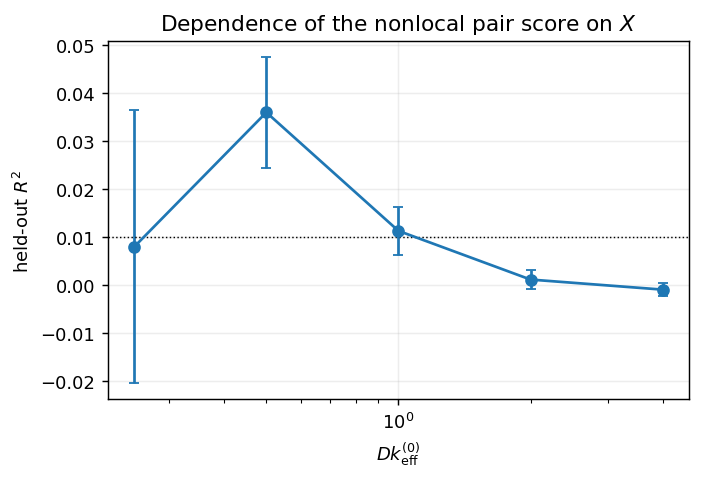

In [3]:
trace_state, nonlocal_scores, trace_groups = trace_nonlocal_table()
finite_trace = np.all(np.isfinite(trace_state), axis=1) & np.all(np.isfinite(nonlocal_scores), axis=1)
trace_state = trace_state[finite_trace]
nonlocal_scores = nonlocal_scores[finite_trace]
trace_groups = trace_groups[finite_trace]
print(f"nonlocal test points: {len(trace_state)}")


def invariant_coordinates(state: np.ndarray, center: np.ndarray | None = None, scale: np.ndarray | None = None):
    positive = np.column_stack((state[:, 0] ** 2, state[:, 1] ** 2, state[:, 2] ** 2))
    transformed = np.log1p(positive)
    if center is None:
        center = np.median(transformed, axis=0)
    if scale is None:
        q25, q75 = np.quantile(transformed, [0.25, 0.75], axis=0)
        scale = np.maximum(q75 - q25, 1e-6)
    transformed = np.clip((transformed - center) / scale, -5.0, 5.0)
    return transformed, np.asarray(center), np.asarray(scale)


def polynomial_basis(coordinates: np.ndarray) -> np.ndarray:
    z1, z2, z3 = coordinates.T
    return np.column_stack((
        np.ones(len(coordinates)), z1, z2, z3,
        z1**2, z2**2, z3**2, z1 * z2, z1 * z3, z2 * z3,
    ))


trace_coordinates, coordinate_center, coordinate_scale = invariant_coordinates(trace_state)
trace_basis = polynomial_basis(trace_coordinates)


def ridge_coefficients(basis: np.ndarray, response: np.ndarray, ridge: float = 2e-3) -> np.ndarray:
    penalty = np.eye(basis.shape[1]) * ridge
    penalty[0, 0] = 0.0
    return np.linalg.solve(basis.T @ basis + penalty, basis.T @ response)


def grouped_cv_r2(basis: np.ndarray, response: np.ndarray, groups: np.ndarray, folds: int = 6) -> np.ndarray:
    unique_groups = np.unique(groups)
    assignment = np.arange(len(unique_groups)) % folds
    rng = np.random.default_rng(4821)
    rng.shuffle(assignment)
    group_to_fold = dict(zip(unique_groups, assignment))
    scores = []
    for fold in range(folds):
        test = np.array([group_to_fold[group] == fold for group in groups])
        train = ~test
        if np.count_nonzero(test) < 20 or np.count_nonzero(train) < basis.shape[1] + 2:
            continue
        beta = ridge_coefficients(basis[train], response[train])
        prediction = basis[test] @ beta
        denominator = np.sum((response[test] - np.mean(response[train])) ** 2)
        scores.append(1.0 - np.sum((response[test] - prediction) ** 2) / max(denominator, 1e-30))
    return np.asarray(scores)


q_models: dict[tuple[float, float], np.ndarray] = {}
dependency_rows: list[dict[str, object]] = []
for column, decay_range in enumerate(DECAY_RANGES):
    response = nonlocal_scores[:, column]
    fold_scores = grouped_cv_r2(trace_basis, response, trace_groups)
    mean_score = float(np.mean(fold_scores))
    score_se = float(np.std(fold_scores, ddof=1) / np.sqrt(len(fold_scores))) if len(fold_scores) > 1 else np.nan
    dependent = bool(mean_score > max(0.01, 2.0 * score_se))
    dependency_rows.append({
        "D_k_eff": decay_range,
        "cv_R2": mean_score,
        "cv_R2_se": score_se,
        "dependent": dependent,
        "score_mean": float(np.mean(response)),
        "score_std": float(np.std(response)),
    })
    for interaction_weight in INTERACTION_WEIGHTS:
        boltzmann = np.exp(-interaction_weight * response)
        q_models[(float(decay_range), float(interaction_weight))] = ridge_coefficients(
            trace_basis, boltzmann
        )

write_rows(OUTPUT_DIR / "q_dependency.csv", dependency_rows)
dependent_ranges = {
    float(row["D_k_eff"]) for row in dependency_rows if bool(row["dependent"])
}
print("nonlocal dependence test")
for row in dependency_rows:
    print(
        f"  D*k_eff={float(row['D_k_eff']):.2f}: "
        f"R2={float(row['cv_R2']):.4f} +/- {float(row['cv_R2_se']):.4f}; "
        f"dependent={row['dependent']}"
    )

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.errorbar(
    [float(row["D_k_eff"]) for row in dependency_rows],
    [float(row["cv_R2"]) for row in dependency_rows],
    yerr=[float(row["cv_R2_se"]) for row in dependency_rows],
    marker="o", capsize=3,
)
ax.axhline(0.01, color="k", lw=0.8, ls=":")
ax.set(xscale="log", xlabel=r"$Dk_{\rm eff}^{(0)}$", ylabel=r"held-out $R^2$", title=r"Dependence of the nonlocal pair score on $X$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "q_dependency_test.png")
plt.show()


def evaluate_log_q(state: np.ndarray, decay_range: float, interaction_weight: float) -> np.ndarray:
    if interaction_weight == 0.0 or decay_range not in dependent_ranges:
        return np.zeros(len(state))
    coordinates, _, _ = invariant_coordinates(state, coordinate_center, coordinate_scale)
    estimate = polynomial_basis(coordinates) @ q_models[(float(decay_range), float(interaction_weight))]
    trace_response = np.exp(-interaction_weight * nonlocal_scores[:, np.where(DECAY_RANGES == decay_range)[0][0]])
    lower = max(float(np.quantile(trace_response, 0.002)), 1e-8)
    upper = min(float(np.quantile(trace_response, 0.998)), 1.0)
    return np.log(np.clip(estimate, lower, upper))


def state_from_local_sample(sample: dict[str, np.ndarray | float]) -> np.ndarray:
    return np.column_stack((
        np.asarray(sample["kappa"]) / REFERENCE_K_EFF,
        np.asarray(sample["kappa_prime"]) / REFERENCE_K_EFF**2,
        np.asarray(sample["kappa_tau"]) / REFERENCE_K_EFF**2,
    ))


## Local reweighting


In [4]:
def local_features(sample: dict[str, np.ndarray | float]) -> np.ndarray:
    return np.column_stack((
        np.asarray(sample["local_second"]) / REFERENCE_K_EFF**2,
        np.asarray(sample["local_fourth"]) / REFERENCE_K_EFF**4,
    ))


def independent_local_features(sample: dict[str, np.ndarray | float]) -> np.ndarray:
    kappa = np.asarray(sample["kappa"])
    kappa_prime = np.asarray(sample["kappa_prime"])
    kappa_tau = np.asarray(sample["kappa_tau"])
    return np.column_stack((
        kappa**2 / REFERENCE_K_EFF**2,
        kappa**4 / REFERENCE_K_EFF**4,
        kappa_prime**2 / REFERENCE_K_EFF**4,
        kappa_tau**2 / REFERENCE_K_EFF**4,
    ))


def independent_density_ratio_fit(
    reference: dict[str, np.ndarray | float],
    target: dict[str, np.ndarray | float],
    train_mask: np.ndarray | None = None,
) -> dict[str, object]:
    """Fit the four local invariants without imposing the Yukawa ratios."""

    reference_features = independent_local_features(reference)
    target_features = independent_local_features(target)
    reference_weights = np.asarray(reference["weights"], dtype=float)
    target_weights = np.asarray(target["weights"], dtype=float)
    bounds = np.vstack([
        weighted_quantile(reference_features[:, index], np.array([0.002, 0.998]), reference_weights)
        for index in range(reference_features.shape[1])
    ])
    reference_keep = np.all(
        (reference_features >= bounds[:, 0]) & (reference_features <= bounds[:, 1]), axis=1
    )
    target_keep = np.all(
        (target_features >= bounds[:, 0]) & (target_features <= bounds[:, 1]), axis=1
    )
    if train_mask is not None:
        reference_keep &= train_mask
        target_keep &= train_mask
    x_ref = reference_features[reference_keep]
    x_target = target_features[target_keep]
    w_ref = reference_weights[reference_keep]
    w_target = target_weights[target_keep]
    w_ref = 0.5 * w_ref / np.sum(w_ref)
    w_target = 0.5 * w_target / np.sum(w_target)
    center = np.sum((2.0 * w_ref[:, None]) * x_ref, axis=0)
    scale = np.sqrt(np.sum((2.0 * w_ref[:, None]) * (x_ref - center) ** 2, axis=0))
    scale = np.maximum(scale, 1e-8)
    design = np.vstack(((x_ref - center) / scale, (x_target - center) / scale))
    design = np.column_stack((np.ones(len(design)), design))
    labels = np.concatenate((np.zeros(len(x_ref)), np.ones(len(x_target))))
    weights = np.concatenate((w_ref, w_target))

    def objective(parameters: np.ndarray) -> tuple[float, np.ndarray]:
        eta = design @ parameters
        loss = np.sum(weights * (np.logaddexp(0.0, eta) - labels * eta))
        probability = 1.0 / (1.0 + np.exp(-np.clip(eta, -40.0, 40.0)))
        gradient = design.T @ (weights * (probability - labels))
        return float(loss), gradient

    result = minimize(
        lambda parameters: objective(parameters),
        np.zeros(design.shape[1]),
        jac=True,
        method="BFGS",
        options={"gtol": 1e-10, "maxiter": 500},
    )
    parameters = np.asarray(result.x)
    eta = design @ parameters
    probability = 1.0 / (1.0 + np.exp(-np.clip(eta, -40.0, 40.0)))
    hessian = design.T @ ((weights * probability * (1.0 - probability))[:, None] * design)
    effective_n = 1.0 / np.sum(weights**2)
    covariance = np.linalg.pinv(hessian * effective_n)
    coefficient = -parameters[1:] / scale
    coefficient_se = np.sqrt(np.diag(covariance)[1:]) / scale
    log_weight = -(x_ref @ coefficient)
    log_weight -= np.max(log_weight)
    tilted = w_ref * np.exp(np.maximum(log_weight, -60.0))
    tilted /= np.sum(tilted)
    return {
        "coefficient": coefficient,
        "coefficient_se": coefficient_se,
        "loss": float(objective(parameters)[0]),
        "success": bool(result.success),
        "reference_keep": reference_keep,
        "target_keep": target_keep,
        "feature_bounds": bounds,
        "target_mass_retained": float(np.sum(target_weights[target_keep])),
        "reference_effective_fraction": float(1.0 / (np.sum(tilted**2) * len(tilted))),
    }


def flexible_local_coordinates(sample: dict[str, np.ndarray | float]) -> np.ndarray:
    """Even local coordinates that preserve the sign symmetries of the ensemble."""

    state = state_from_local_sample(sample)
    return np.log1p(state**2)


def polynomial_exponents(variable_count: int, maximum_degree: int) -> list[tuple[int, ...]]:
    exponents: list[tuple[int, ...]] = []
    for degree in range(1, maximum_degree + 1):
        for indices in combinations_with_replacement(range(variable_count), degree):
            exponent = [0] * variable_count
            for index in indices:
                exponent[index] += 1
            exponents.append(tuple(exponent))
    return exponents


FLEXIBLE_EXPONENTS = polynomial_exponents(3, FLEXIBLE_LOCAL_DEGREE)
SEPARABLE_EXPONENTS = [
    exponent
    for exponent in FLEXIBLE_EXPONENTS
    if exponent[1] == 0 or (exponent[0] == 0 and exponent[2] == 0)
]
KAPPA_TAU_EXPONENTS = [
    exponent for exponent in FLEXIBLE_EXPONENTS if exponent[1] == 0
]


def flexible_polynomial_matrix(
    coordinates: np.ndarray,
    exponents: list[tuple[int, ...]] = FLEXIBLE_EXPONENTS,
) -> np.ndarray:
    return np.column_stack([
        np.prod(coordinates ** np.asarray(exponent), axis=1)
        for exponent in exponents
    ])


def flexible_density_ratio_fit(
    reference: dict[str, np.ndarray | float],
    target: dict[str, np.ndarray | float],
    train_mask: np.ndarray | None = None,
    exponents: list[tuple[int, ...]] = FLEXIBLE_EXPONENTS,
) -> dict[str, object]:
    """Fit a smooth local log-density ratio without imposing Yukawa ratios."""

    reference_weights = np.asarray(reference["weights"], dtype=float)
    target_weights = np.asarray(target["weights"], dtype=float)
    if train_mask is None:
        train_mask = np.ones(len(reference_weights), dtype=bool)
    reference_weights_train = reference_weights[train_mask]
    target_weights_train = target_weights[train_mask]
    reference_weights_train /= np.sum(reference_weights_train)
    target_weights_train /= np.sum(target_weights_train)

    reference_coordinates_raw = flexible_local_coordinates(reference)
    target_coordinates_raw = flexible_local_coordinates(target)
    coordinate_center = np.sum(
        reference_weights_train[:, None] * reference_coordinates_raw[train_mask], axis=0
    )
    coordinate_scale = np.sqrt(np.sum(
        reference_weights_train[:, None]
        * (reference_coordinates_raw[train_mask] - coordinate_center) ** 2,
        axis=0,
    ))
    coordinate_scale = np.maximum(coordinate_scale, 1e-8)
    reference_coordinates = np.clip(
        (reference_coordinates_raw - coordinate_center) / coordinate_scale, -5.0, 5.0
    )
    target_coordinates = np.clip(
        (target_coordinates_raw - coordinate_center) / coordinate_scale, -5.0, 5.0
    )

    reference_terms_raw = flexible_polynomial_matrix(reference_coordinates, exponents)
    target_terms_raw = flexible_polynomial_matrix(target_coordinates, exponents)
    term_center = np.sum(
        reference_weights_train[:, None] * reference_terms_raw[train_mask], axis=0
    )
    term_scale = np.sqrt(np.sum(
        reference_weights_train[:, None]
        * (reference_terms_raw[train_mask] - term_center) ** 2,
        axis=0,
    ))
    term_scale = np.maximum(term_scale, 1e-8)
    reference_terms = (reference_terms_raw - term_center) / term_scale
    target_terms = (target_terms_raw - term_center) / term_scale

    reference_design = np.column_stack((
        np.ones(np.count_nonzero(train_mask)), reference_terms[train_mask]
    ))
    target_design = np.column_stack((
        np.ones(np.count_nonzero(train_mask)), target_terms[train_mask]
    ))
    design = np.vstack((reference_design, target_design))
    labels = np.concatenate((
        np.zeros(len(reference_design)), np.ones(len(target_design))
    ))
    weights = np.concatenate((
        0.5 * reference_weights_train, 0.5 * target_weights_train
    ))

    def objective(parameters: np.ndarray) -> tuple[float, np.ndarray]:
        eta = design @ parameters
        probability = 1.0 / (1.0 + np.exp(-np.clip(eta, -40.0, 40.0)))
        loss = np.sum(weights * (np.logaddexp(0.0, eta) - labels * eta))
        loss += 0.5 * FLEXIBLE_LOCAL_RIDGE * np.dot(parameters[1:], parameters[1:])
        gradient = design.T @ (weights * (probability - labels))
        gradient[1:] += FLEXIBLE_LOCAL_RIDGE * parameters[1:]
        return float(loss), gradient

    result = minimize(
        lambda parameters: objective(parameters),
        np.zeros(design.shape[1]),
        jac=True,
        method="L-BFGS-B",
        options={"ftol": 1e-12, "maxiter": 400},
    )
    return {
        "parameters": np.asarray(result.x),
        "coordinate_center": coordinate_center,
        "coordinate_scale": coordinate_scale,
        "term_center": term_center,
        "term_scale": term_scale,
        "exponents": exponents,
        "loss": float(objective(np.asarray(result.x))[0]),
        "success": bool(result.success),
    }


def evaluate_flexible_log_ratio(
    sample: dict[str, np.ndarray | float],
    fit: dict[str, object],
) -> np.ndarray:
    return evaluate_flexible_log_ratio_from_state(state_from_local_sample(sample), fit)


def evaluate_flexible_log_ratio_from_state(
    state: np.ndarray,
    fit: dict[str, object],
) -> np.ndarray:
    coordinates = np.clip(
        (np.log1p(np.asarray(state)**2) - np.asarray(fit["coordinate_center"]))
        / np.asarray(fit["coordinate_scale"]),
        -5.0,
        5.0,
    )
    terms = (
        flexible_polynomial_matrix(coordinates, list(fit["exponents"]))
        - np.asarray(fit["term_center"])
    ) / np.asarray(fit["term_scale"])
    design = np.column_stack((np.ones(len(terms)), terms))
    return design @ np.asarray(fit["parameters"])


def density_ratio_fit(
    reference: dict[str, np.ndarray | float],
    target: dict[str, np.ndarray | float],
    reference_offset: np.ndarray,
    target_offset: np.ndarray,
    train_mask: np.ndarray | None = None,
) -> dict[str, object]:
    reference_features = local_features(reference)
    target_features = local_features(target)
    reference_weights = np.asarray(reference["weights"], dtype=float)
    target_weights = np.asarray(target["weights"], dtype=float)
    bounds = np.vstack([
        weighted_quantile(reference_features[:, index], np.array([0.002, 0.998]), reference_weights)
        for index in range(2)
    ])
    reference_keep = np.all((reference_features >= bounds[:, 0]) & (reference_features <= bounds[:, 1]), axis=1)
    target_keep = np.all((target_features >= bounds[:, 0]) & (target_features <= bounds[:, 1]), axis=1)
    if train_mask is not None:
        reference_keep &= train_mask
        target_keep &= train_mask
    if np.count_nonzero(reference_keep) < 100 or np.count_nonzero(target_keep) < 100:
        raise RuntimeError("Insufficient overlap with the local reference support")
    x_ref = reference_features[reference_keep]
    x_target = target_features[target_keep]
    w_ref = reference_weights[reference_keep]
    w_target = target_weights[target_keep]
    w_ref = 0.5 * w_ref / np.sum(w_ref)
    w_target = 0.5 * w_target / np.sum(w_target)
    center = np.sum((w_ref[:, None] * 2.0) * x_ref, axis=0)
    scale = np.sqrt(np.sum((w_ref[:, None] * 2.0) * (x_ref - center) ** 2, axis=0))
    scale = np.maximum(scale, 1e-8)
    design = np.vstack(((x_ref - center) / scale, (x_target - center) / scale))
    design = np.column_stack((np.ones(len(design)), design))
    labels = np.concatenate((np.zeros(len(x_ref)), np.ones(len(x_target))))
    weights = np.concatenate((w_ref, w_target))
    offset = np.concatenate((reference_offset[reference_keep], target_offset[target_keep]))

    def objective(parameters: np.ndarray) -> tuple[float, np.ndarray]:
        eta = design @ parameters + offset
        loss = np.sum(weights * (np.logaddexp(0.0, eta) - labels * eta))
        probability = 1.0 / (1.0 + np.exp(-np.clip(eta, -40.0, 40.0)))
        gradient = design.T @ (weights * (probability - labels))
        return float(loss), gradient

    result = minimize(
        lambda parameters: objective(parameters),
        np.zeros(3),
        jac=True,
        method="BFGS",
        options={"gtol": 1e-10, "maxiter": 400},
    )
    parameters = np.asarray(result.x)
    eta = design @ parameters + offset
    probability = 1.0 / (1.0 + np.exp(-np.clip(eta, -40.0, 40.0)))
    hessian = design.T @ ((weights * probability * (1.0 - probability))[:, None] * design)
    effective_n = 1.0 / np.sum(weights**2)
    covariance = np.linalg.pinv(hessian * effective_n)
    coefficient = -parameters[1:] / scale
    coefficient_se = np.sqrt(np.diag(covariance)[1:]) / scale
    reference_log_weight = (
        -coefficient[0] * x_ref[:, 0]
        -coefficient[1] * x_ref[:, 1]
        +reference_offset[reference_keep]
    )
    reference_log_weight -= np.max(reference_log_weight)
    reference_tilt = w_ref * np.exp(np.maximum(reference_log_weight, -60.0))
    reference_tilt /= np.sum(reference_tilt)
    effective_fraction = float(
        1.0 / (np.sum(reference_tilt**2) * len(reference_tilt))
    )
    return {
        "delta_c2_kref": float(coefficient[0]),
        "delta_B_kref3": float(coefficient[1]),
        "delta_c2_kref_se": float(coefficient_se[0]),
        "delta_B_kref3_se": float(coefficient_se[1]),
        "intercept": float(parameters[0]),
        "loss": float(objective(parameters)[0]),
        "success": bool(result.success),
        "target_mass_retained": float(np.sum(target_weights[target_keep])),
        "reference_effective_fraction": effective_fraction,
        "reference_keep": reference_keep,
        "target_keep": target_keep,
        "feature_bounds": bounds,
    }


relative interaction coefficients
       0 mM  Delta(c2*kref)= 0 +/- 0  Delta(B*kref^3)= 0 +/- 0  D*kref=0  weight=0  reference ESS fraction=1
       1 mM  Delta(c2*kref)= 0.0005173 +/- 0.011  Delta(B*kref^3)=-0.00017347 +/- 0.0098  D*kref=0.5  weight=1.5  reference ESS fraction=0.679
      10 mM  Delta(c2*kref)= 0.030582 +/- 0.011  Delta(B*kref^3)=-0.014541 +/- 0.01  D*kref=1  weight=2  reference ESS fraction=0.668
      24 mM  Delta(c2*kref)=-0.058097 +/- 0.01  Delta(B*kref^3)= 0.020581 +/- 0.0096  D*kref=0  weight=0  reference ESS fraction=0.697
      40 mM  Delta(c2*kref)=-0.11746 +/- 0.011  Delta(B*kref^3)= 0.044667 +/- 0.0097  D*kref=0  weight=0  reference ESS fraction=0.713
      55 mM  Delta(c2*kref)=-0.26965 +/- 0.012  Delta(B*kref^3)= 0.11875 +/- 0.01  D*kref=0  weight=0  reference ESS fraction=0.529
      70 mM  Delta(c2*kref)=-0.32719 +/- 0.012  Delta(B*kref^3)= 0.14817 +/- 0.01  D*kref=0  weight=0  reference ESS fraction=0.149
     100 mM  Delta(c2*kref)=-0.3612 +/- 0.012 

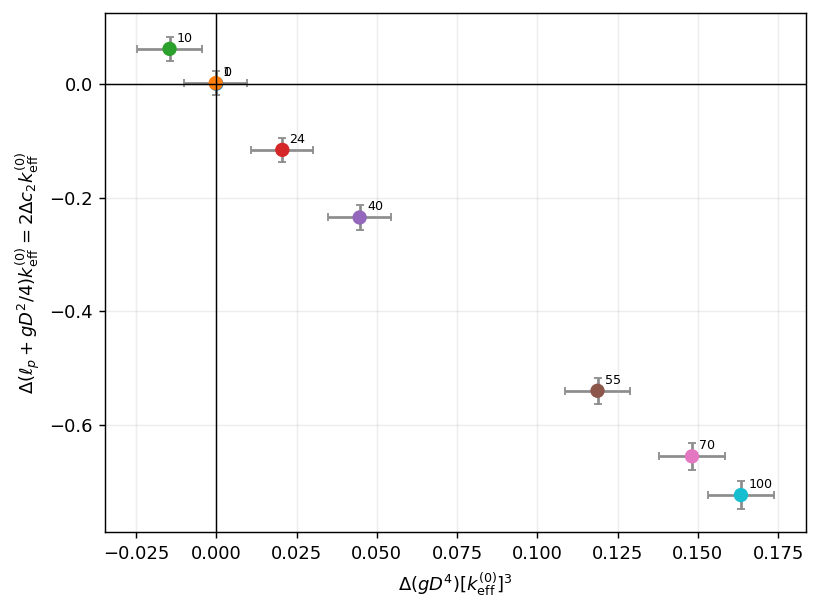

In [5]:
reference_sample = local_samples[REFERENCE_SALT]
reference_state = state_from_local_sample(reference_sample)
split_mask = np.arange(len(reference_state)) % 2 == 0
interaction_rows: list[dict[str, object]] = []
fit_objects: dict[float, dict[str, object]] = {}

for row in fit_series:
    concentration = float(row["concentration_mM"])
    if concentration == REFERENCE_SALT:
        interaction_rows.append({
            "concentration_mM": concentration,
            "delta_c2_kref": 0.0,
            "delta_c2_kref_se": 0.0,
            "delta_B_kref3": 0.0,
            "delta_B_kref3_se": 0.0,
            "D_k_eff": 0.0,
            "interaction_weight": 0.0,
            "q_dependent": False,
            "target_mass_retained": 1.0,
            "reference_effective_fraction": 1.0,
            "test_loss": np.nan,
        })
        continue
    target_sample = local_samples[concentration]
    target_state = state_from_local_sample(target_sample)
    candidates: list[tuple[float, float, float, dict[str, object]]] = []
    for decay_range in DECAY_RANGES:
        for interaction_weight in INTERACTION_WEIGHTS:
            if interaction_weight > 0.0 and decay_range not in dependent_ranges:
                continue
            ref_offset = evaluate_log_q(reference_state, float(decay_range), float(interaction_weight))
            target_offset = evaluate_log_q(target_state, float(decay_range), float(interaction_weight))
            training = density_ratio_fit(
                reference_sample, target_sample, ref_offset, target_offset, train_mask=split_mask
            )
            test = density_ratio_fit(
                reference_sample, target_sample, ref_offset, target_offset, train_mask=~split_mask
            )
            candidates.append((float(test["loss"]), float(decay_range), float(interaction_weight), training))
    candidates.sort(key=lambda item: item[0])
    test_loss, best_decay, best_weight, _ = candidates[0]
    if best_weight == 0.0:
        best_decay = 0.0
    reference_offset = evaluate_log_q(reference_state, best_decay, best_weight)
    target_offset = evaluate_log_q(target_state, best_decay, best_weight)
    final_fit = density_ratio_fit(reference_sample, target_sample, reference_offset, target_offset)
    final_fit.update({
        "decay_range": best_decay,
        "interaction_weight": best_weight,
        "reference_log_q": reference_offset,
        "target_log_q": target_offset,
    })
    fit_objects[concentration] = final_fit
    interaction_rows.append({
        "concentration_mM": concentration,
        "delta_c2_kref": final_fit["delta_c2_kref"],
        "delta_c2_kref_se": final_fit["delta_c2_kref_se"],
        "delta_B_kref3": final_fit["delta_B_kref3"],
        "delta_B_kref3_se": final_fit["delta_B_kref3_se"],
        "D_k_eff": best_decay,
        "interaction_weight": best_weight,
        "q_dependent": bool(best_weight > 0.0 and best_decay in dependent_ranges),
        "target_mass_retained": final_fit["target_mass_retained"],
        "reference_effective_fraction": final_fit["reference_effective_fraction"],
        "test_loss": test_loss,
    })

interaction_rows.sort(key=lambda row: float(row["concentration_mM"]))
write_rows(OUTPUT_DIR / "interaction_changes.csv", interaction_rows)
print("relative interaction coefficients")
for row in interaction_rows:
    print(
        f"  {float(row['concentration_mM']):6g} mM  "
        f"Delta(c2*kref)={float(row['delta_c2_kref']): .5g} +/- {float(row['delta_c2_kref_se']):.2g}  "
        f"Delta(B*kref^3)={float(row['delta_B_kref3']): .5g} +/- {float(row['delta_B_kref3_se']):.2g}  "
        f"D*kref={float(row['D_k_eff']):.2g}  weight={float(row['interaction_weight']):.2g}  "
        f"reference ESS fraction={float(row.get('reference_effective_fraction', 1.0)):.3g}"
    )


independent_names = ("kappa2", "kappa4", "kappa_prime2", "kappa2_tau2")
independent_rows: list[dict[str, object]] = []
independent_fit_objects: dict[float, dict[str, object]] = {}
for row in fit_series:
    concentration = float(row["concentration_mM"])
    if concentration == REFERENCE_SALT:
        independent_rows.append({
            "concentration_mM": concentration,
            **{f"delta_{name}": 0.0 for name in independent_names},
            **{f"delta_{name}_se": 0.0 for name in independent_names},
            "target_mass_retained": 1.0,
            "reference_effective_fraction": 1.0,
            "loss": np.nan,
        })
        continue
    fit = independent_density_ratio_fit(reference_sample, local_samples[concentration])
    independent_fit_objects[concentration] = fit
    coefficients = np.asarray(fit["coefficient"])
    coefficient_se = np.asarray(fit["coefficient_se"])
    independent_rows.append({
        "concentration_mM": concentration,
        **{f"delta_{name}": float(coefficients[index]) for index, name in enumerate(independent_names)},
        **{f"delta_{name}_se": float(coefficient_se[index]) for index, name in enumerate(independent_names)},
        "target_mass_retained": fit["target_mass_retained"],
        "reference_effective_fraction": fit["reference_effective_fraction"],
        "loss": fit["loss"],
    })

independent_rows.sort(key=lambda row: float(row["concentration_mM"]))
write_rows(OUTPUT_DIR / "independent_local_invariant_changes.csv", independent_rows)

flexible_fit_objects: dict[float, dict[str, object]] = {}
separable_fit_objects: dict[float, dict[str, object]] = {}
flexible_rows: list[dict[str, object]] = []
for row in fit_series:
    concentration = float(row["concentration_mM"])
    if concentration == REFERENCE_SALT:
        continue
    fit = flexible_density_ratio_fit(reference_sample, local_samples[concentration])
    separable_fit = flexible_density_ratio_fit(
        reference_sample,
        local_samples[concentration],
        exponents=SEPARABLE_EXPONENTS,
    )
    flexible_fit_objects[concentration] = fit
    separable_fit_objects[concentration] = separable_fit
    reference_log_ratio = evaluate_flexible_log_ratio(reference_sample, fit)
    reference_log_ratio -= np.max(reference_log_ratio)
    flexible_weights = np.asarray(reference_sample["weights"]) * np.exp(
        np.maximum(reference_log_ratio, -60.0)
    )
    flexible_weights /= np.sum(flexible_weights)
    flexible_rows.append({
        "concentration_mM": concentration,
        "polynomial_degree": FLEXIBLE_LOCAL_DEGREE,
        "full_shape_terms": len(FLEXIBLE_EXPONENTS),
        "separable_shape_terms": len(SEPARABLE_EXPONENTS),
        "kappa_kappa_tau_shape_terms": len(KAPPA_TAU_EXPONENTS),
        "ridge": FLEXIBLE_LOCAL_RIDGE,
        "fit_success": fit["success"],
        "separable_fit_success": separable_fit["success"],
        "loss": fit["loss"],
        "reference_effective_fraction": float(
            1.0 / (np.sum(flexible_weights**2) * len(flexible_weights))
        ),
    })
write_rows(OUTPUT_DIR / "nonlinear_local_reconstruction.csv", flexible_rows)


combined_interaction_rows: list[dict[str, object]] = []
for row in interaction_rows:
    concentration = float(row["concentration_mM"])
    delta_lp_effective = 2.0 * float(row["delta_c2_kref"])
    delta_range_moment = float(row["delta_B_kref3"])
    combined_interaction_rows.append({
        "concentration_mM": concentration,
        "delta_lp_effective_kref": delta_lp_effective,
        "delta_lp_effective_kref_se": 2.0 * float(row["delta_c2_kref_se"]),
        "delta_gD4_kref3": delta_range_moment,
        "delta_gD4_kref3_se": float(row["delta_B_kref3_se"]),
        "direction_if_bare_lp_is_constant": (
            "stronger_and_shorter_ranged"
            if delta_lp_effective > 0.0 and delta_range_moment < 0.0
            else "reference" if concentration == REFERENCE_SALT else "not_assigned"
        ),
    })
write_rows(OUTPUT_DIR / "combined_interaction_changes.csv", combined_interaction_rows)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
interaction_x = np.array([float(row["delta_gD4_kref3"]) for row in combined_interaction_rows])
interaction_y = np.array([float(row["delta_lp_effective_kref"]) for row in combined_interaction_rows])
interaction_c = np.array([float(row["concentration_mM"]) for row in combined_interaction_rows])
ax.errorbar(
    interaction_x,
    interaction_y,
    xerr=[float(row["delta_gD4_kref3_se"]) for row in combined_interaction_rows],
    yerr=[float(row["delta_lp_effective_kref_se"]) for row in combined_interaction_rows],
    fmt="none", ecolor="0.55", capsize=2, zorder=1,
)
points = ax.scatter(
    interaction_x, interaction_y,
    color=[salt_color_map[float(value)] for value in interaction_c],
    s=48, zorder=2,
)
for x_value, y_value, concentration in zip(interaction_x, interaction_y, interaction_c):
    ax.annotate(f"{concentration:g}", (x_value, y_value), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.axhline(0.0, color="k", lw=0.8)
ax.axvline(0.0, color="k", lw=0.8)
ax.set(
    xlabel=r"$\Delta(gD^4)[k_{\rm eff}^{(0)}]^3$",
    ylabel=r"$\Delta(\ell_p+gD^2/4)k_{\rm eff}^{(0)}=2\Delta c_2k_{\rm eff}^{(0)}$",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "combined_interaction_change.png")
plt.show()


def reweighted_reference_weights(concentration: float) -> np.ndarray:
    fit = fit_objects[concentration]
    features = local_features(reference_sample)
    exponent = (
        -float(fit["delta_c2_kref"]) * features[:, 0]
        -float(fit["delta_B_kref3"]) * features[:, 1]
        +np.asarray(fit["reference_log_q"])
    )
    keep = np.asarray(fit["reference_keep"], dtype=bool)
    exponent -= np.max(exponent[keep])
    weights = np.zeros(len(exponent))
    weights[keep] = np.asarray(reference_sample["weights"])[keep] * np.exp(
        np.maximum(exponent[keep], -60.0)
    )
    return weights / np.sum(weights)


def independently_reweighted_reference_weights(concentration: float) -> np.ndarray:
    fit = independent_fit_objects[concentration]
    features = independent_local_features(reference_sample)
    exponent = -(features @ np.asarray(fit["coefficient"]))
    keep = np.asarray(fit["reference_keep"], dtype=bool)
    exponent -= np.max(exponent[keep])
    weights = np.zeros(len(exponent))
    weights[keep] = np.asarray(reference_sample["weights"])[keep] * np.exp(
        np.maximum(exponent[keep], -60.0)
    )
    return weights / np.sum(weights)


def nonlinearly_reweighted_reference_weights(concentration: float) -> np.ndarray:
    log_ratio = evaluate_flexible_log_ratio(
        reference_sample, flexible_fit_objects[concentration]
    )
    log_ratio -= np.max(log_ratio)
    weights = np.asarray(reference_sample["weights"]) * np.exp(
        np.maximum(log_ratio, -60.0)
    )
    return weights / np.sum(weights)


def separably_reweighted_reference_weights(concentration: float) -> np.ndarray:
    log_ratio = evaluate_flexible_log_ratio(
        reference_sample, separable_fit_objects[concentration]
    )
    log_ratio -= np.max(log_ratio)
    weights = np.asarray(reference_sample["weights"]) * np.exp(
        np.maximum(log_ratio, -60.0)
    )
    return weights / np.sum(weights)


def tilted_subset_weights(
    base_weights: np.ndarray,
    log_ratio: np.ndarray,
    subset: np.ndarray,
) -> np.ndarray:
    local_log_ratio = np.asarray(log_ratio)[subset]
    local_log_ratio -= np.max(local_log_ratio)
    weights = np.asarray(base_weights)[subset] * np.exp(
        np.maximum(local_log_ratio, -60.0)
    )
    return weights / np.sum(weights)


def weighted_ks_distance(
    first_values: np.ndarray,
    first_weights: np.ndarray,
    second_values: np.ndarray,
    second_weights: np.ndarray,
) -> float:
    first_order = np.argsort(first_values)
    second_order = np.argsort(second_values)
    first_values = np.asarray(first_values)[first_order]
    second_values = np.asarray(second_values)[second_order]
    first_weights = np.asarray(first_weights)[first_order]
    second_weights = np.asarray(second_weights)[second_order]
    first_cdf = np.cumsum(first_weights) / np.sum(first_weights)
    second_cdf = np.cumsum(second_weights) / np.sum(second_weights)
    grid = np.unique(np.concatenate((first_values, second_values)))
    first_on_grid = np.interp(grid, first_values, first_cdf, left=0.0, right=1.0)
    second_on_grid = np.interp(grid, second_values, second_cdf, left=0.0, right=1.0)
    return float(np.max(np.abs(first_on_grid - second_on_grid)))


def heldout_log_loss_difference(
    reference: dict[str, np.ndarray | float],
    target: dict[str, np.ndarray | float],
    separable_fit: dict[str, object],
    full_fit: dict[str, object],
    test_mask: np.ndarray,
) -> tuple[float, float, float, float]:
    reference_weights = np.asarray(reference["weights"])[test_mask]
    target_weights = np.asarray(target["weights"])[test_mask]
    reference_weights /= np.sum(reference_weights)
    target_weights /= np.sum(target_weights)
    separable_reference = evaluate_flexible_log_ratio(reference, separable_fit)[test_mask]
    separable_target = evaluate_flexible_log_ratio(target, separable_fit)[test_mask]
    full_reference = evaluate_flexible_log_ratio(reference, full_fit)[test_mask]
    full_target = evaluate_flexible_log_ratio(target, full_fit)[test_mask]
    separable_loss = 0.5 * (
        np.sum(reference_weights * np.logaddexp(0.0, separable_reference))
        +np.sum(target_weights * np.logaddexp(0.0, -separable_target))
    )
    full_loss = 0.5 * (
        np.sum(reference_weights * np.logaddexp(0.0, full_reference))
        +np.sum(target_weights * np.logaddexp(0.0, -full_target))
    )
    reference_difference = (
        np.logaddexp(0.0, separable_reference)
        -np.logaddexp(0.0, full_reference)
    )
    target_difference = (
        np.logaddexp(0.0, -separable_target)
        -np.logaddexp(0.0, -full_target)
    )

    def weighted_standard_error(values: np.ndarray, weights: np.ndarray) -> float:
        mean = np.sum(weights * values)
        variance = np.sum(weights * (values - mean) ** 2)
        effective_count = 1.0 / np.sum(weights**2)
        return float(np.sqrt(variance / effective_count))

    difference_se = 0.5 * np.sqrt(
        weighted_standard_error(reference_difference, reference_weights) ** 2
        +weighted_standard_error(target_difference, target_weights) ** 2
    )
    return float(separable_loss), float(full_loss), float(separable_loss - full_loss), float(difference_se)


## Reconstruction checks


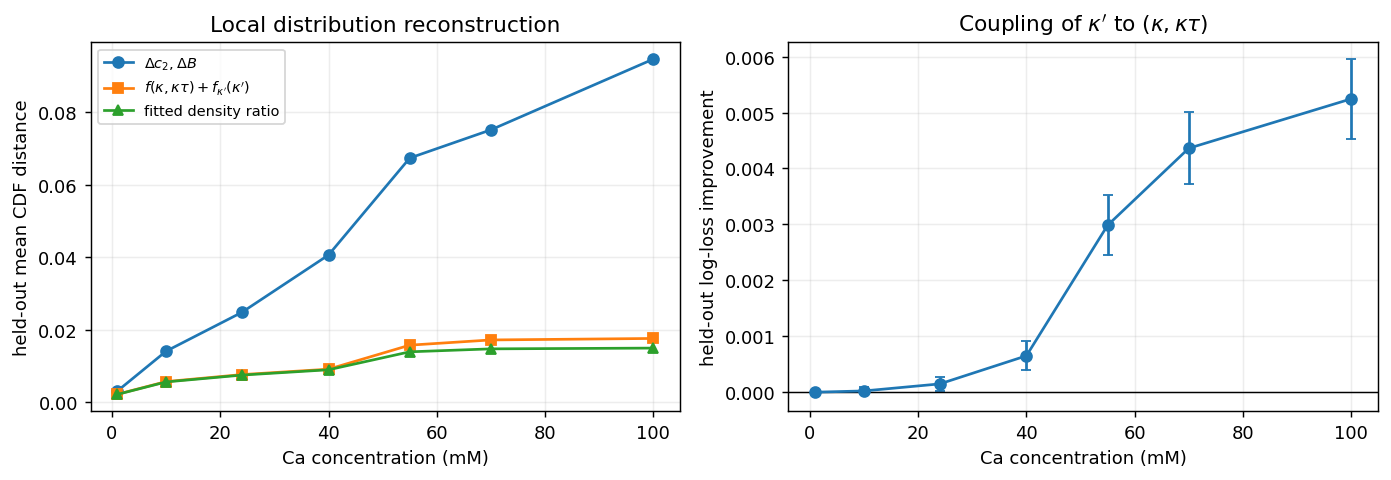

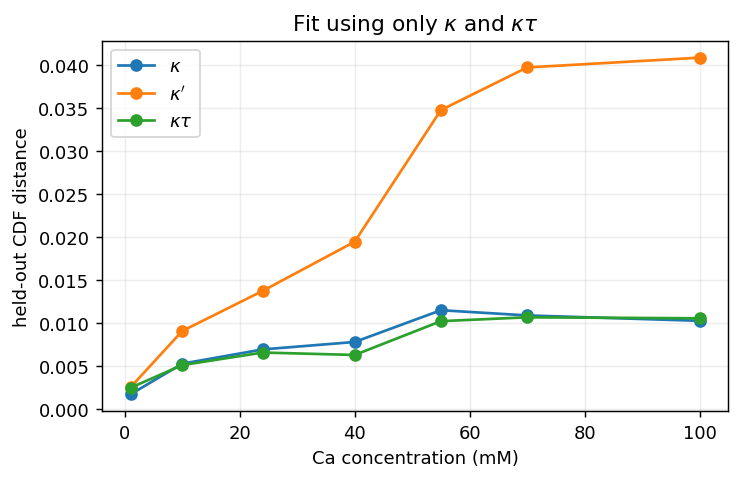

In [6]:
quality_rng = np.random.default_rng(9123)
quality_train = quality_rng.random(len(np.asarray(reference_sample["weights"]))) < FLEXIBLE_TRAIN_FRACTION
quality_test = ~quality_train
quality_rows: list[dict[str, object]] = []
for concentration in sorted(fit_objects):
    target = local_samples[concentration]
    zero_reference_offset = np.zeros(len(np.asarray(reference_sample["weights"])))
    zero_target_offset = np.zeros(len(np.asarray(target["weights"])))
    linked_fit = density_ratio_fit(
        reference_sample,
        target,
        zero_reference_offset,
        zero_target_offset,
        train_mask=quality_train,
    )
    independent_fit = independent_density_ratio_fit(
        reference_sample, target, train_mask=quality_train
    )
    flexible_fit = flexible_density_ratio_fit(
        reference_sample, target, train_mask=quality_train
    )
    separable_fit = flexible_density_ratio_fit(
        reference_sample,
        target,
        train_mask=quality_train,
        exponents=SEPARABLE_EXPONENTS,
    )
    kappa_tau_fit = flexible_density_ratio_fit(
        reference_sample,
        target,
        train_mask=quality_train,
        exponents=KAPPA_TAU_EXPONENTS,
    )
    reference_local_features = local_features(reference_sample)
    linked_log_ratio = (
        -float(linked_fit["delta_c2_kref"]) * reference_local_features[:, 0]
        -float(linked_fit["delta_B_kref3"]) * reference_local_features[:, 1]
    )
    independent_log_ratio = -(
        independent_local_features(reference_sample)
        @ np.asarray(independent_fit["coefficient"])
    )
    flexible_log_ratio = evaluate_flexible_log_ratio(reference_sample, flexible_fit)
    separable_log_ratio = evaluate_flexible_log_ratio(reference_sample, separable_fit)
    kappa_tau_log_ratio = evaluate_flexible_log_ratio(reference_sample, kappa_tau_fit)
    linked_bounds = np.asarray(linked_fit["feature_bounds"])
    linked_reference_test = quality_test & np.all(
        (reference_local_features >= linked_bounds[:, 0])
        & (reference_local_features <= linked_bounds[:, 1]),
        axis=1,
    )
    reference_independent_features = independent_local_features(reference_sample)
    independent_bounds = np.asarray(independent_fit["feature_bounds"])
    independent_reference_test = quality_test & np.all(
        (reference_independent_features >= independent_bounds[:, 0])
        & (reference_independent_features <= independent_bounds[:, 1]),
        axis=1,
    )
    linked_weights = tilted_subset_weights(
        np.asarray(reference_sample["weights"]), linked_log_ratio, linked_reference_test
    )
    independent_weights = tilted_subset_weights(
        np.asarray(reference_sample["weights"]), independent_log_ratio, independent_reference_test
    )
    flexible_weights = tilted_subset_weights(
        np.asarray(reference_sample["weights"]), flexible_log_ratio, quality_test
    )
    separable_weights = tilted_subset_weights(
        np.asarray(reference_sample["weights"]), separable_log_ratio, quality_test
    )
    kappa_tau_weights = tilted_subset_weights(
        np.asarray(reference_sample["weights"]), kappa_tau_log_ratio, quality_test
    )
    target_test_weights = np.asarray(target["weights"])[quality_test]
    row: dict[str, object] = {"concentration_mM": concentration}
    linked_distances: list[float] = []
    independent_distances: list[float] = []
    flexible_distances: list[float] = []
    separable_distances: list[float] = []
    kappa_tau_distances: list[float] = []
    for name, _, _ in geometry_specs:
        target_values = np.asarray(target[name])[quality_test]
        linked_reference_values = np.asarray(reference_sample[name])[linked_reference_test]
        independent_reference_values = np.asarray(reference_sample[name])[independent_reference_test]
        flexible_reference_values = np.asarray(reference_sample[name])[quality_test]
        linked_distance = weighted_ks_distance(
            target_values, target_test_weights, linked_reference_values, linked_weights
        )
        independent_distance = weighted_ks_distance(
            target_values, target_test_weights, independent_reference_values, independent_weights
        )
        flexible_distance = weighted_ks_distance(
            target_values, target_test_weights, flexible_reference_values, flexible_weights
        )
        separable_distance = weighted_ks_distance(
            target_values, target_test_weights, flexible_reference_values, separable_weights
        )
        kappa_tau_distance = weighted_ks_distance(
            target_values, target_test_weights, flexible_reference_values, kappa_tau_weights
        )
        row[f"KS_{name}_linked"] = linked_distance
        row[f"KS_{name}_independent"] = independent_distance
        row[f"KS_{name}_nonlinear"] = flexible_distance
        row[f"KS_{name}_separable"] = separable_distance
        row[f"KS_{name}_without_kappa_prime"] = kappa_tau_distance
        linked_distances.append(linked_distance)
        independent_distances.append(independent_distance)
        flexible_distances.append(flexible_distance)
        separable_distances.append(separable_distance)
        kappa_tau_distances.append(kappa_tau_distance)
    row["KS_mean_linked"] = float(np.mean(linked_distances))
    row["KS_mean_independent"] = float(np.mean(independent_distances))
    row["KS_mean_nonlinear"] = float(np.mean(flexible_distances))
    row["KS_mean_separable"] = float(np.mean(separable_distances))
    row["KS_mean_without_kappa_prime"] = float(np.mean(kappa_tau_distances))
    (
        row["log_loss_separable"],
        row["log_loss_full"],
        row["log_loss_cross_term_improvement"],
        row["log_loss_cross_term_improvement_se"],
    ) = heldout_log_loss_difference(
        reference_sample,
        target,
        separable_fit,
        flexible_fit,
        quality_test,
    )
    quality_rows.append(row)

write_rows(OUTPUT_DIR / "reconstruction_quality.csv", quality_rows)
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8))
axes[0].plot(
    [float(row["concentration_mM"]) for row in quality_rows],
    [float(row["KS_mean_linked"]) for row in quality_rows],
    "o-", label=r"$\Delta c_2,\Delta B$",
)
axes[0].plot(
    [float(row["concentration_mM"]) for row in quality_rows],
    [float(row["KS_mean_separable"]) for row in quality_rows],
    "s-", label=r"$f(\kappa,\kappa\tau)+f_{\kappa'}(\kappa')$",
)
axes[0].plot(
    [float(row["concentration_mM"]) for row in quality_rows],
    [float(row["KS_mean_nonlinear"]) for row in quality_rows],
    "^-", label="fitted density ratio",
)
axes[0].set(
    xlabel="Ca concentration (mM)",
    ylabel="held-out mean CDF distance",
    title="Local distribution reconstruction",
)
axes[0].legend(fontsize=8)
axes[1].errorbar(
    [float(row["concentration_mM"]) for row in quality_rows],
    [float(row["log_loss_cross_term_improvement"]) for row in quality_rows],
    yerr=[float(row["log_loss_cross_term_improvement_se"]) for row in quality_rows],
    marker="o", capsize=3,
)
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set(
    xlabel="Ca concentration (mM)",
    ylabel="held-out log-loss improvement",
    title=r"Coupling of $\kappa'$ to $(\kappa,\kappa\tau)$",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "reconstruction_quality.png")
plt.show()

fig, ax = plt.subplots(figsize=(5.8, 3.8))
for name, label in (
    ("kappa", r"$\kappa$"),
    ("kappa_prime", r"$\kappa'$"),
    ("kappa_tau", r"$\kappa\tau$"),
):
    ax.plot(
        [float(row["concentration_mM"]) for row in quality_rows],
        [float(row[f"KS_{name}_without_kappa_prime"]) for row in quality_rows],
        marker="o",
        label=label,
    )
ax.set(
    xlabel="Ca concentration (mM)",
    ylabel="held-out CDF distance",
    title=r"Fit using only $\kappa$ and $\kappa\tau$",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kappa_prime_omission_test.png")
plt.show()


## Traced salt series


In [7]:
def trace_cache_for_condition(concentration: float) -> Path:
    if concentration == REFERENCE_SALT:
        return trace_cache
    return OUTPUT_DIR / f"trace_{int(round(concentration)):03d}mM_isotropic.npz"


def traced_state_for_condition(row: dict[str, float | str]) -> np.ndarray:
    concentration = float(row["concentration_mM"])
    width = float(row["r_sigma_k"])
    fitted_k_eff = float(row["k_eff"])
    trace_k0 = trace_k0_for_spectrum(fitted_k_eff, width)
    cache_path = trace_cache_for_condition(concentration)
    if concentration == REFERENCE_SALT:
        condition_trace = trace
    else:
        condition_trace = load_trace_cache(
            cache_path, width, trace_k0, TRACE_RANDOM_SEED
        )
        if condition_trace is None:
            print(f"tracing {concentration:g} mM")
            condition_trace = build_isotropic_trace(
                width, trace_k0, TRACE_RANDOM_SEED
            )
            save_trace_cache(
                cache_path,
                *condition_trace,
                width,
                trace_k0,
                TRACE_RANDOM_SEED,
            )
    _, local_tangent_cells, local_r2_cells, local_r3_cells, local_trace_k_eff = condition_trace
    state = np.vstack([
        local_trace_state(tangent, r2_values, r3_values, local_trace_k_eff)
        for tangent, r2_values, r3_values in zip(
            local_tangent_cells, local_r2_cells, local_r3_cells
        )
    ])
    physical_scale = fitted_k_eff / REFERENCE_K_EFF
    state[:, 0] *= physical_scale
    state[:, 1:] *= physical_scale**2
    return state[np.all(np.isfinite(state), axis=1)]


tracing 1 mM
tracing 10 mM
tracing 24 mM
tracing 40 mM
tracing 55 mM
tracing 70 mM
tracing 100 mM
traced local points: 0 mM=40559, 1 mM=40617, 10 mM=34712, 24 mM=32679, 40 mM=29813, 55 mM=33698, 70 mM=27869, 100 mM=24890


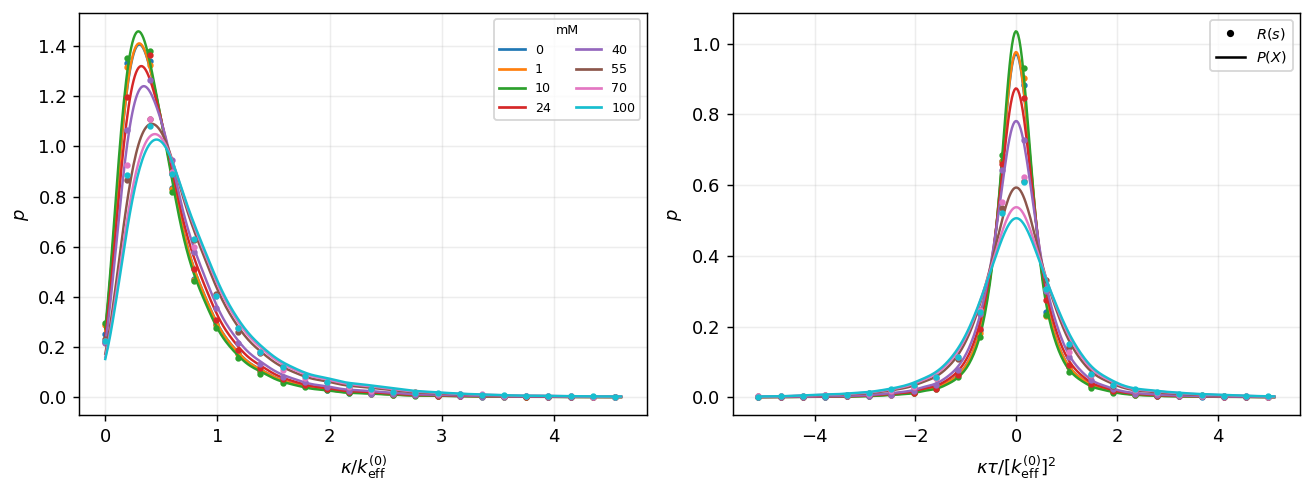

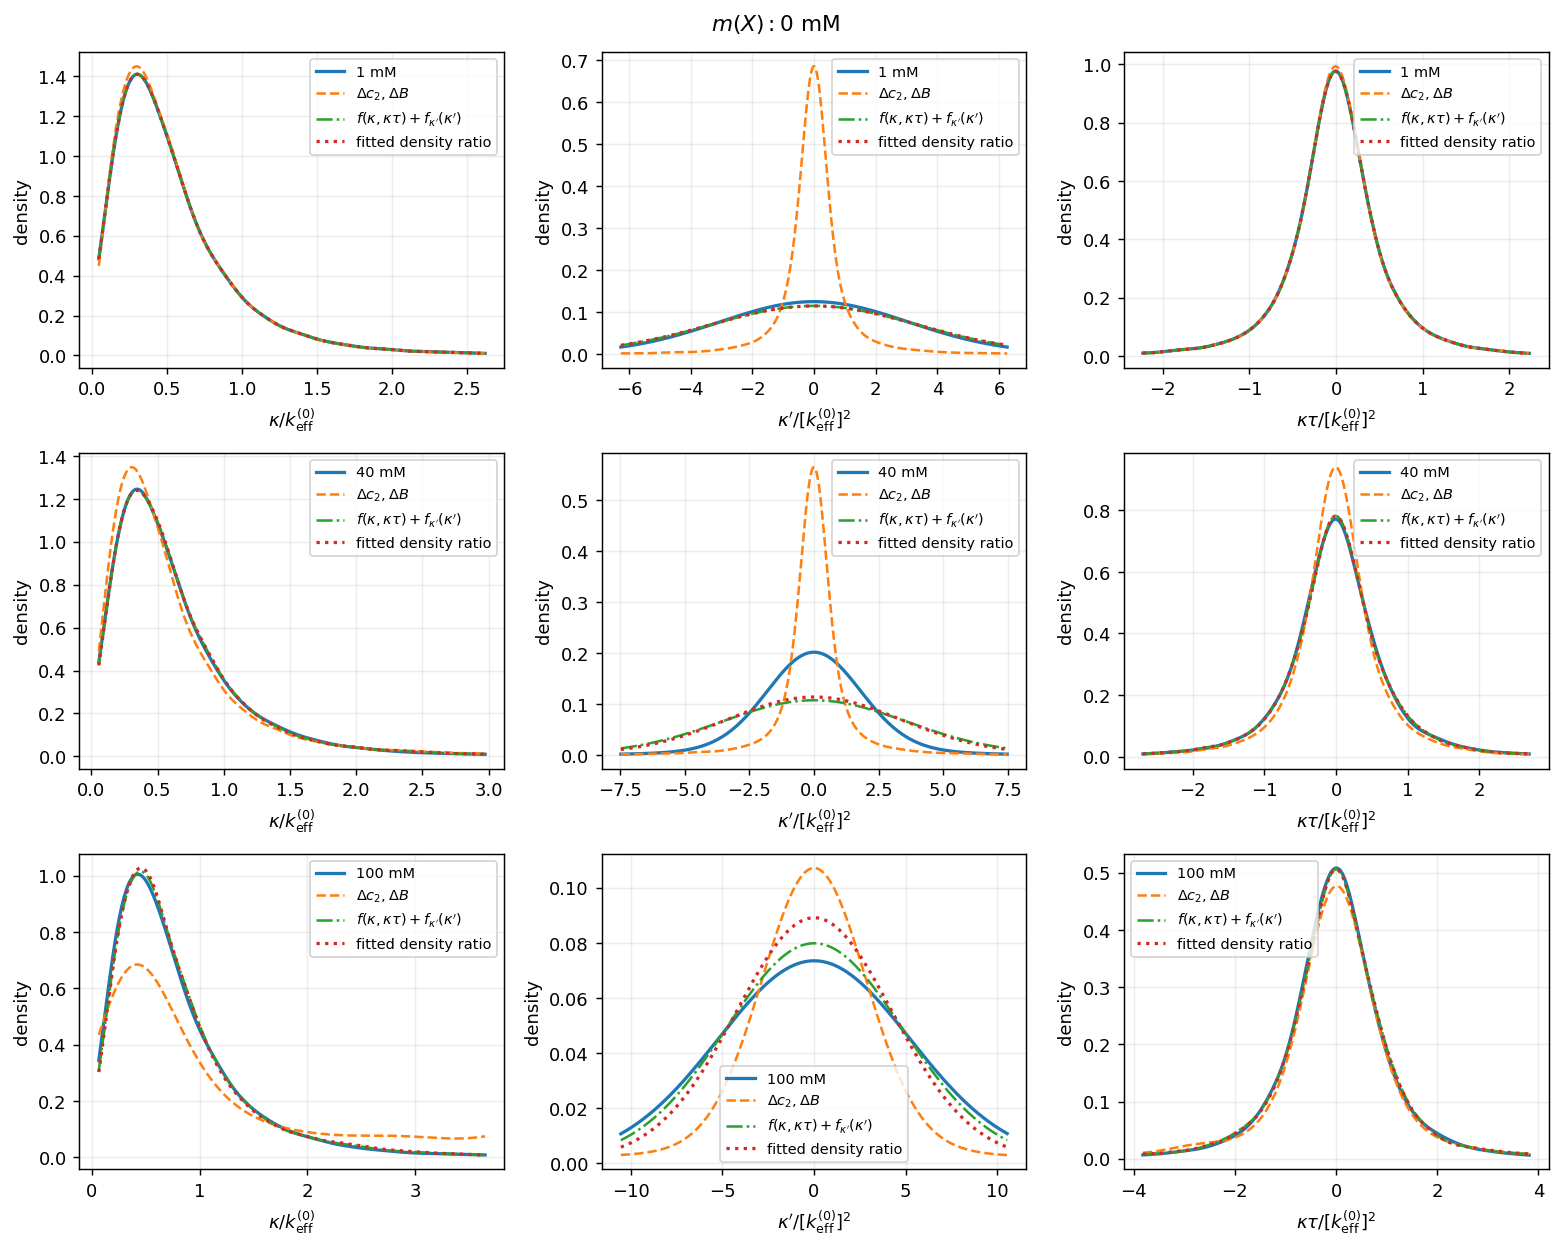

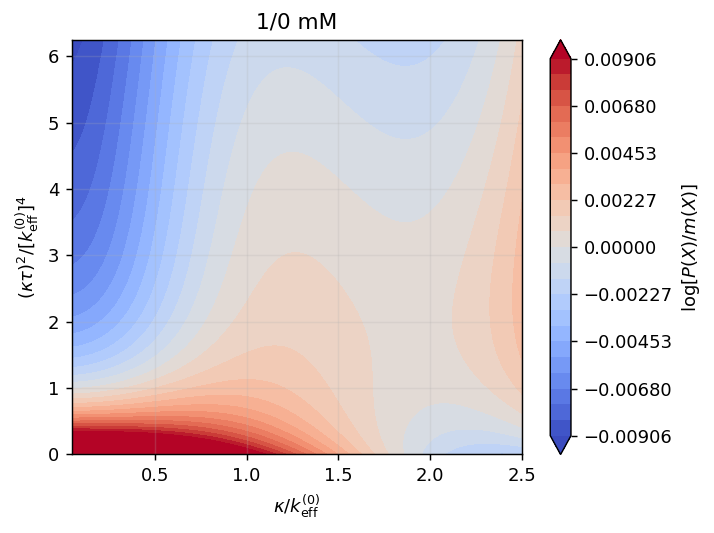

saved interaction analysis to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\curvefit\output\ca_interaction_0mM_aniso


In [8]:
traced_local_states = {
    float(row["concentration_mM"]): traced_state_for_condition(row)
    for row in fit_series
}
traced_counts = {
    concentration: len(state) for concentration, state in traced_local_states.items()
}
print("traced local points: " + ", ".join(
    f"{concentration:g} mM={traced_counts[concentration]}"
    for concentration in sorted(traced_counts)
))

trace_state_arrays = [
    traced_local_states[float(row["concentration_mM"])] for row in fit_series
]
trace_state_offsets = np.concatenate((
    [0], np.cumsum([len(state) for state in trace_state_arrays])
))
np.savez_compressed(
    OUTPUT_DIR / "traced_local_geometry_samples.npz",
    concentrations_mM=np.array([
        float(row["concentration_mM"]) for row in fit_series
    ]),
    states=np.vstack(trace_state_arrays),
    offsets=trace_state_offsets,
)

trace_reconstruction_specs = (
    (0, "kappa", r"$\kappa/k_{\rm eff}^{(0)}$"),
    (2, "kappa_tau", r"$\kappa\tau/[k_{\rm eff}^{(0)}]^2$"),
)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))
trace_distribution_rows: list[dict[str, object]] = []
for axis, (state_column, name, xlabel) in zip(axes, trace_reconstruction_specs):
    pooled_bounds = []
    for row in fit_series:
        concentration = float(row["concentration_mM"])
        scale = REFERENCE_K_EFF if name == "kappa" else REFERENCE_K_EFF**2
        values = np.asarray(local_samples[concentration][name]) / scale
        pooled_bounds.append(weighted_quantile(
            values,
            np.array([0.005, 0.995]),
            np.asarray(local_samples[concentration]["weights"]),
        ))
    pooled_bounds = np.asarray(pooled_bounds)
    if name == "kappa":
        grid = np.linspace(0.0, float(np.max(pooled_bounds[:, 1])), 420)
    else:
        limit = float(np.max(np.abs(pooled_bounds)))
        grid = np.linspace(-limit, limit, 420)
    for color, row in zip(colors, fit_series):
        concentration = float(row["concentration_mM"])
        traced_values = traced_local_states[concentration][:, state_column]
        traced_density = kde_curve(
            traced_values, np.ones(len(traced_values)), grid
        )
        if concentration == REFERENCE_SALT:
            reproduced_weights = np.asarray(reference_sample["weights"])
        else:
            reproduced_weights = nonlinearly_reweighted_reference_weights(concentration)
        reproduced_values = np.asarray(reference_sample[name]) / (
            REFERENCE_K_EFF if name == "kappa" else REFERENCE_K_EFF**2
        )
        reproduced_density = kde_curve(
            reproduced_values, reproduced_weights, grid
        )
        axis.plot(grid, reproduced_density, color=color, lw=1.35)
        axis.plot(
            grid[::18], traced_density[::18],
            linestyle="none", marker="o", ms=2.5, color=color,
        )
        for grid_value, trace_value, reproduced_value in zip(
            grid, traced_density, reproduced_density
        ):
            trace_distribution_rows.append({
                "concentration_mM": concentration,
                "quantity": name,
                "coordinate": float(grid_value),
                "traced_density": float(trace_value),
                "reproduced_density": float(reproduced_value),
            })
    axis.set(xlabel=xlabel, ylabel=r"$p$")

concentration_handles = [
    Line2D([0], [0], color=color, lw=1.5, label=f"{float(row['concentration_mM']):g}")
    for color, row in zip(colors, fit_series)
]
style_handles = [
    Line2D([0], [0], color="k", marker="o", linestyle="none", ms=3, label=r"$R(s)$"),
    Line2D([0], [0], color="k", lw=1.4, label=r"$P(X)$"),
]
axes[0].legend(handles=concentration_handles, title="mM", ncol=2, fontsize=7, title_fontsize=7)
axes[1].legend(handles=style_handles, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "trace_local_reconstruction.png")
plt.show()
write_rows(OUTPUT_DIR / "trace_local_reconstruction.csv", trace_distribution_rows)


comparison_conditions = [
    float(row["concentration_mM"])
    for row in fit_series
    if float(row["concentration_mM"]) != REFERENCE_SALT
]
comparison_conditions = [comparison_conditions[0], comparison_conditions[len(comparison_conditions) // 2], comparison_conditions[-1]]
fig, axes = plt.subplots(len(comparison_conditions), 3, figsize=(12.2, 3.25 * len(comparison_conditions)))
for row_index, concentration in enumerate(comparison_conditions):
    target = local_samples[concentration]
    predicted_weights = reweighted_reference_weights(concentration)
    separable_weights = separably_reweighted_reference_weights(concentration)
    nonlinear_weights = nonlinearly_reweighted_reference_weights(concentration)
    for axis, (name, scale, label) in zip(axes[row_index], geometry_specs):
        ref_values = np.asarray(reference_sample[name]) / scale
        target_values = np.asarray(target[name]) / scale
        bounds = weighted_quantile(target_values, np.array([0.01, 0.99]), np.asarray(target["weights"]))
        if name != "kappa":
            symmetric = max(abs(bounds[0]), abs(bounds[1]))
            bounds = np.array([-symmetric, symmetric])
        grid = np.linspace(bounds[0], bounds[1], 350)
        axis.plot(grid, kde_curve(target_values, np.asarray(target["weights"]), grid), lw=1.8, label=f"{concentration:g} mM")
        axis.plot(grid, kde_curve(ref_values, predicted_weights, grid), "--", lw=1.4, label=r"$\Delta c_2,\Delta B$")
        axis.plot(grid, kde_curve(ref_values, separable_weights, grid), "-.", lw=1.4, label=r"$f(\kappa,\kappa\tau)+f_{\kappa'}(\kappa')$")
        axis.plot(grid, kde_curve(ref_values, nonlinear_weights, grid), ":", lw=1.8, label="fitted density ratio")
        axis.set(xlabel=label, ylabel="density")
        axis.legend(fontsize=8)
fig.suptitle(fr"$m(X): {REFERENCE_SALT:g}\ {{\rm mM}}$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interaction_reweighted_distributions.png")
plt.show()


display_condition = comparison_conditions[0]
display_fit = flexible_fit_objects[display_condition]
kappa_grid = np.linspace(0.05, 2.5, 160)
kappa_tau2_grid = np.linspace(0.0, 2.5**2, 180)
mesh_kappa, mesh_kappa_tau2 = np.meshgrid(kappa_grid, kappa_tau2_grid)
display_state = np.column_stack((
    mesh_kappa.ravel(),
    np.zeros(mesh_kappa.size),
    np.sqrt(mesh_kappa_tau2.ravel()),
))
display_log_ratio = evaluate_flexible_log_ratio_from_state(
    display_state, display_fit
)
display_log_ratio -= np.median(display_log_ratio)
ratio_limit = np.quantile(np.abs(display_log_ratio), 0.98)
fig, ax = plt.subplots(figsize=(5.6, 4.2))
image = ax.contourf(
    mesh_kappa,
    mesh_kappa_tau2,
    display_log_ratio.reshape(mesh_kappa.shape),
    levels=np.linspace(-ratio_limit, ratio_limit, 25),
    cmap="coolwarm",
    extend="both",
)
fig.colorbar(image, ax=ax, label=r"$\log[P(X)/m(X)]$")
ax.set(
    xlabel=r"$\kappa/k_{\rm eff}^{(0)}$",
    ylabel=r"$(\kappa\tau)^2/[k_{\rm eff}^{(0)}]^4$",
    title=f"{display_condition:g}/{REFERENCE_SALT:g} mM",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interaction_change_map.png")
plt.show()


np.savez_compressed(
    OUTPUT_DIR / "local_geometry_samples.npz",
    concentrations_mM=np.array([float(row["concentration_mM"]) for row in fit_series]),
    k_eff=np.array([float(row["k_eff"]) for row in fit_series]),
    r_sigma_k=np.array([float(row["r_sigma_k"]) for row in fit_series]),
    kappa=np.stack([np.asarray(local_samples[float(row["concentration_mM"])]["kappa"]) for row in fit_series]),
    kappa_prime=np.stack([np.asarray(local_samples[float(row["concentration_mM"])]["kappa_prime"]) for row in fit_series]),
    kappa_tau=np.stack([np.asarray(local_samples[float(row["concentration_mM"])]["kappa_tau"]) for row in fit_series]),
    line_weights=np.stack([np.asarray(local_samples[float(row["concentration_mM"])]["weights"]) for row in fit_series]),
    trace_state=trace_state,
    nonlocal_scores=nonlocal_scores,
    decay_ranges=DECAY_RANGES,
)

print(f"saved interaction analysis to {OUTPUT_DIR}")


## $c_2$, $B$, $g$, and $D$


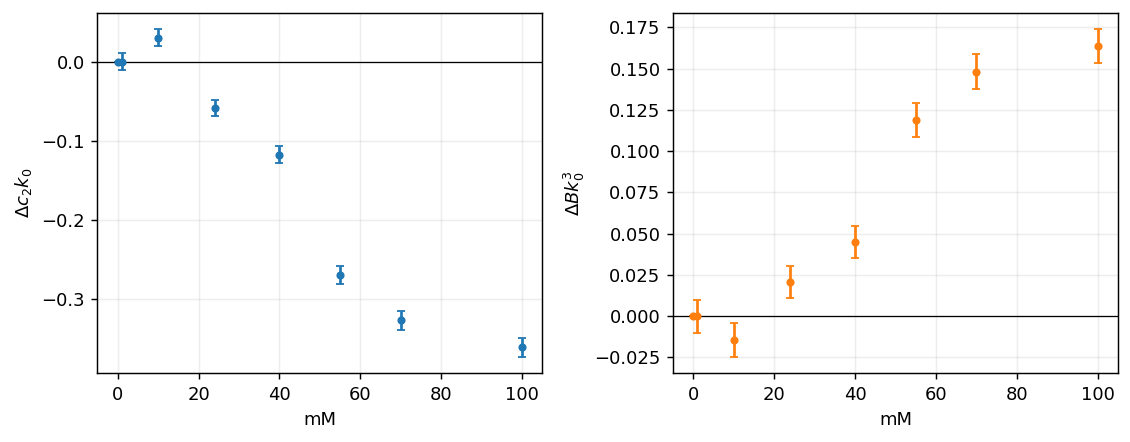

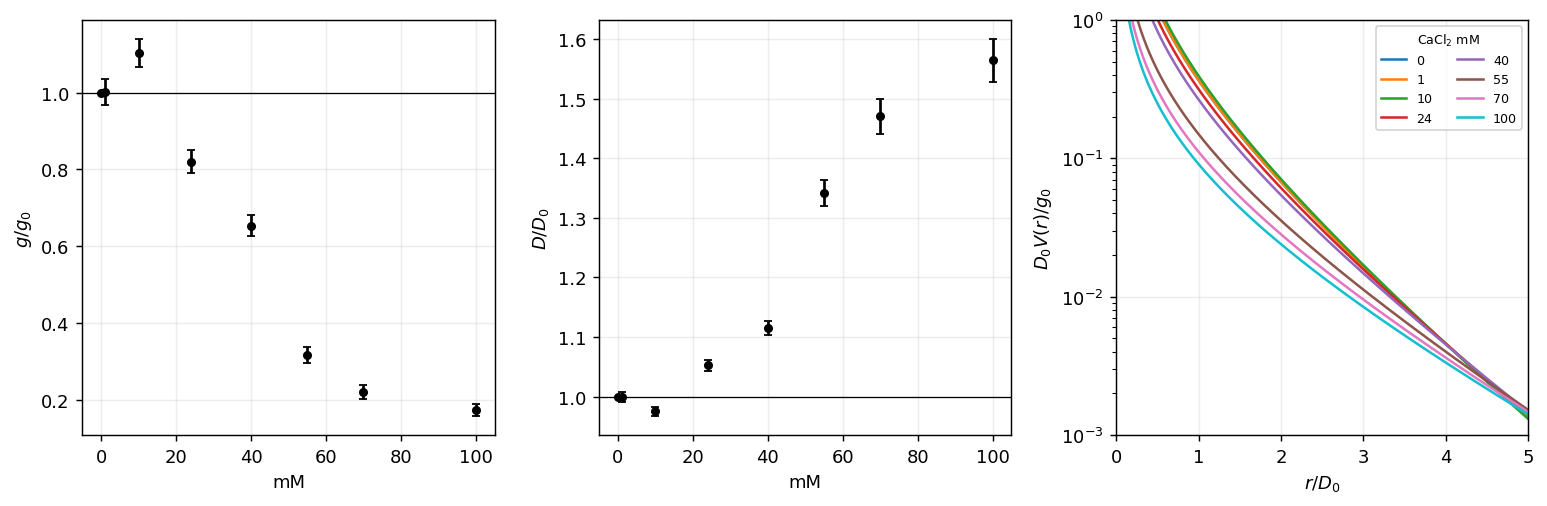

g_ref/k_ref = 5; D_ref k_ref = 1
0 mM: g/g_ref=1.000 +/- 0.000; D/D_ref=1.000 +/- 0.000
1 mM: g/g_ref=1.002 +/- 0.034; D/D_ref=1.000 +/- 0.008
10 mM: g/g_ref=1.103 +/- 0.036; D/D_ref=0.975 +/- 0.008
24 mM: g/g_ref=0.819 +/- 0.030; D/D_ref=1.052 +/- 0.010
40 mM: g/g_ref=0.654 +/- 0.027; D/D_ref=1.115 +/- 0.012
55 mM: g/g_ref=0.316 +/- 0.021; D/D_ref=1.342 +/- 0.022
70 mM: g/g_ref=0.221 +/- 0.018; D/D_ref=1.470 +/- 0.030
100 mM: g/g_ref=0.173 +/- 0.016; D/D_ref=1.564 +/- 0.036


In [9]:
report_rows = sorted(
    interaction_rows,
    key=lambda row: float(row["concentration_mM"]),
)
salt = np.array([float(row["concentration_mM"]) for row in report_rows])
delta_c2 = np.array([float(row["delta_c2_kref"]) for row in report_rows])
delta_c2_se = np.array([float(row["delta_c2_kref_se"]) for row in report_rows])
delta_B = np.array([float(row["delta_B_kref3"]) for row in report_rows])
delta_B_se = np.array([float(row["delta_B_kref3_se"]) for row in report_rows])

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharex=True)
for axis, values, errors, ylabel, color in (
    (axes[0], delta_c2, delta_c2_se, r"$\Delta c_2 k_{0}$", "C0"),
    (axes[1], delta_B, delta_B_se, r"$\Delta B k_{0}^3$", "C1"),
):
    axis.errorbar(salt, values, yerr=errors, marker="o", ms=3.5, capsize=2, color=color, linestyle="none", zorder=2)
    axis.axhline(0.0, color="k", lw=0.7)
    axis.set(xlabel="mM", ylabel=ylabel)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "c2_B_changes.png")
plt.show()

# Reference normalization for converting the fitted product changes to
# continuous relative trends in g and D. These are assumptions, not fitted
# chemical parameters.
D_REF_KREF = 1.0
G_REF_OVER_KREF = 5.0
A_reference = G_REF_OVER_KREF * D_REF_KREF**2
B_reference = G_REF_OVER_KREF * D_REF_KREF**4

# c2 = ell_p/2 + g D^2/8. With constant ell_p,
# Delta[(g D^2) k_ref] = 8 Delta(c2 k_ref).
A_values = A_reference + 8.0 * delta_c2
A_errors = 8.0 * delta_c2_se
B_values = B_reference + delta_B
B_errors = delta_B_se
if np.any(A_values <= 0.0) or np.any(B_values <= 0.0):
    raise ValueError("The selected g_ref and D_ref do not keep g D^2 and g D^4 positive")

D_relative = np.sqrt((B_values / B_reference) / (A_values / A_reference))
g_relative = (A_values / A_reference) ** 2 / (B_values / B_reference)
D_relative_se = 0.5 * D_relative * np.sqrt(
    (A_errors / A_values) ** 2 + (B_errors / B_values) ** 2
)
g_relative_se = g_relative * np.sqrt(
    (2.0 * A_errors / A_values) ** 2 + (B_errors / B_values) ** 2
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, values, errors, ylabel in (
    (axes[0], g_relative, g_relative_se, r"$g/g_{0}$"),
    (axes[1], D_relative, D_relative_se, r"$D/D_{0}$"),
):
    # axis.plot(salt, values, color="0.55", lw=0.9, zorder=1)
    for concentration, value, error in zip(salt, values, errors):
        axis.errorbar(
            concentration, value, yerr=error,
            marker="o", ms=4.0, capsize=2,
            color="k", zorder=2, linestyle="none",
        )
    axis.axhline(1.0, color="k", lw=0.7)
    axis.set(xlabel="mM", ylabel=ylabel)

reduced_r = np.linspace(0.1, 6.0, 500)
reduced_potential_columns = [reduced_r]
reduced_potential_names = ["r_over_D_ref"]
for concentration, g_value, D_value in zip(salt, g_relative, D_relative):
    reduced_potential = g_value * np.exp(-reduced_r / D_value) / reduced_r
    reduced_potential_columns.append(reduced_potential)
    reduced_potential_names.append(f"V_{concentration:g}mM")
    axes[2].plot(
        reduced_r, reduced_potential,
        color=salt_color_map[float(concentration)], lw=1.4,
        label=f"{concentration:g}",
    )
axes[2].set(
    xlabel=r"$r/D_{0}$",
    ylabel=r"$D_{0}V(r)/g_{0}$",
    yscale="log",
    xlim=(0,5),
    ylim=(1e-3,1)
)
axes[2].legend(title=r"CaCl$_2$ mM", ncol=2, fontsize=7, title_fontsize=7)
np.savetxt(
    OUTPUT_DIR / "reduced_pair_potential.csv",
    np.column_stack(reduced_potential_columns),
    delimiter=",",
    header=",".join(reduced_potential_names),
    comments="",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "relative_g_D.png")
plt.show()

# x_margin = 0.08 * max(np.ptp(delta_c2), 0.05)
# y_margin = 0.08 * max(np.ptp(delta_B), 0.02)
# x_grid = np.linspace(np.min(delta_c2) - x_margin, np.max(delta_c2) + x_margin, 220)
# y_grid = np.linspace(np.min(delta_B) - y_margin, np.max(delta_B) + y_margin, 220)
# mesh_c2, mesh_B = np.meshgrid(x_grid, y_grid)
# mesh_A_value = A_reference + 8.0 * mesh_c2
# mesh_B_value = B_reference + mesh_B
# valid = (mesh_A_value > 0.0) & (mesh_B_value > 0.0)
# mesh_D_relative = np.full(mesh_A_value.shape, np.nan)
# mesh_g_relative = np.full(mesh_A_value.shape, np.nan)
# mesh_D_relative[valid] = np.sqrt(
#     (mesh_B_value[valid] / B_reference) /
#     (mesh_A_value[valid] / A_reference)
# )
# mesh_g_relative[valid] = (
#     (mesh_A_value[valid] / A_reference) ** 2 /
#     (mesh_B_value[valid] / B_reference)
# )

# def contour_levels(field, count=7):
#     finite = np.asarray(field)[np.isfinite(field)]
#     lower, upper = np.quantile(finite, [0.02, 0.98])
#     return np.linspace(lower, upper, count)

# fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.9), constrained_layout=True)
# points = None
# for axis, field, title in (
#     (axes[0], mesh_g_relative, r"$g/g_{0}$"),
#     (axes[1], mesh_D_relative, r"$D/D_{0}$"),
# ):
#     contours = axis.contour(
#         mesh_c2, mesh_B, field,
#         levels=contour_levels(field), colors="0.35", linewidths=0.8,
#     )
#     axis.clabel(contours, inline=True, fontsize=6, fmt="%.2g")
#     points = axis.scatter(
#         delta_c2, delta_B,
#         color=[salt_color_map[float(value)] for value in salt],
#         s=34, zorder=3,
#     )
#     for x_value, y_value, concentration in zip(delta_c2, delta_B, salt):
#         axis.annotate(
#             f"{concentration:g}", (x_value, y_value),
#             xytext=(3, 3), textcoords="offset points", fontsize=6.5,
#         )
#     axis.axhline(0.0, color="k", lw=0.6)
#     axis.axvline(0.0, color="k", lw=0.6)
#     axis.set(
#         xlabel=r"$\Delta c_2 k_{0}$",
#         ylabel=r"$\Delta B k_{0}^3$",
#         title=title,
#     )
# fig.savefig(OUTPUT_DIR / "c2_B_g_D_contours.png")
# plt.show()

relative_rows = []
for concentration, c2_value, c2_error, B_value, B_error, g_value, g_error, D_value, D_error in zip(
    salt, delta_c2, delta_c2_se, delta_B, delta_B_se,
    g_relative, g_relative_se, D_relative, D_relative_se,
):
    relative_rows.append({
        "concentration_mM": concentration,
        "delta_c2_kref": c2_value,
        "delta_c2_kref_se": c2_error,
        "delta_B_kref3": B_value,
        "delta_B_kref3_se": B_error,
        "g_over_g_ref": g_value,
        "g_over_g_ref_se": g_error,
        "D_over_D_ref": D_value,
        "D_over_D_ref_se": D_error,
        "assumed_g_ref_over_kref": G_REF_OVER_KREF,
        "assumed_D_ref_kref": D_REF_KREF,
    })
write_rows(OUTPUT_DIR / "relative_g_D.csv", relative_rows)

print(f"g_ref/k_ref = {G_REF_OVER_KREF:g}; D_ref k_ref = {D_REF_KREF:g}")
for row in relative_rows:
    print(
        f"{float(row['concentration_mM']):g} mM: "
        f"g/g_ref={float(row['g_over_g_ref']):.3f} +/- {float(row['g_over_g_ref_se']):.3f}; "
        f"D/D_ref={float(row['D_over_D_ref']):.3f} +/- {float(row['D_over_D_ref_se']):.3f}"
    )
